# PROYECTO ABP: **Laboratorio de Análisis Agropecuario: Estrategia de fidelización y análisis de demanda**


**Espacio Curricular:** Práctica profesionalizante y Testeo de software  
<br>
Docentes:

- Ahumada Carolina
- Accietto Dianela
<br>
Integrantes del Equipo XX

| Apellido y Nombre               | DNI       | Mail                              |
|---------------------------------|-----------|-----------------------------------|
| Cabana, Enzo Alan Bail          | 36048872  | enzo.cabana.1@gmail.com           |
| Calero, Juan                    | 43231250  | marcelocalero5@gmail.com          |
| Fava Perez, Maria Pia           | 30722626  | piafava@gmail.com                 |
| Maldonado, Sabrina Elizabeth    | 35579029  | sabrina.e.maldonado@gmail.com     |
| Ortega, Santiago Andrés         | 32739392  | ortegasantiagoandres@gmail.com    |
| Strada, Julieta                 | 30124731  | julieta.strada@gmail.com          |

## **PRESENTACIÓN DEL PROYECTO**

### **1. Tipo de Proyecto. Tecnológico Y de Investigación**

### **2. Abstract.**

Este proyecto desarrolla una solucion de **Business Intelligence y Analítica Avanzada** sobre la base transaccional de un Laboratorio Agropecuario para mitigar la fuga de clientes (Churn) y la incertidumbre operativa. Mediante el procesamiento de mas de 8000 registros, el analisis transforma datos historicos en indicadores criticos de fidelización y previsión de demanda. El resultado permitira a la alta direccion y  a las areas de operaciones anticipar picos estacionales de cultivos y ejecutar acciones preventivas de retencion, otpimizacion el uso de recursos tecnicos y financieros.






### **3. Contexto Comercial y Analítico**


El laboratorio opera actualmente bajo un modelo reactivo, lo que se traduce en una "ceguera" comercial: no se detecta la pérdida de clientes hasta que el impacto financiero es irreversible. Operativamente, la falta de previsibilidad en la demanda genera cuellos de botella en la capacidad instalada (personal e insumos).

Enfoque Analítico: Se adoptará una metodología Descriptiva-Diagnóstica y su proyección a Predictiva.

* Alcance: Segmentación de cartera, análisis de distribución de demanda y construcción de un sistema de alertas tempranas.

* Hipótesis de Trabajo: "La implementación de un sistema de monitoreo basado en la frecuencia de envío y volumen de muestras permitirá reducir el Churn Rate mediante la detección temprana de clientes detractores y optimizar la compra de insumos estacionales."


### **4. Fuente de Datos**

Origen: Base de Datos Operativa (SQL) interna, suministrada en formato CSV para el proceso de extracción.

Volumen: ~8100 registros transaccionales desde Junio 2020.

Entidades Clave:

* Clientes: Id_cliente y Razón Social (Dimensiones de segmentación). Solo se trabajará con el ID cliente como referencia a fin de proteger datos sensibles.

* Muestras: muestra (id de muestra), Fechas (Ingreso/certificación), Especie de cultivo.

* Transacciones: Precios de lista.


### **5. Preguntas / Hipótesis a Resolver mediante el Análisis de Datos**

1- Concentración y Riesgo: ¿Qué porcentaje de la facturación depende del "Top 20" de clientes (Pareto) y cuál es su nivel de fidelidad?

2- Análisis de Churn: ¿Cuál es la ventana de tiempo promedio antes de que un cliente se considere "en riesgo de abandono"?

3- Dinámica de Demanda: ¿Cómo varían los picos de trabajo entre especies?


### **6. Objetivos**


Transformar los registros transaccionales estructurados del laboratorio agropecuario en un modelo de segmentación de clientes y análisis de series temporales para optimizar los recursos, mitigar la fuga de clientes y diseñar estrategias comerciales de retención proactiva.

Objetivos Específicos
* OBJETIVO 1: Identificación de clientes frecuentes. Analizar la demanda identificando clientes frecuentes por época del año y especie.
Adicional: Desarrollar un indicador de Alerta de Churn para clientes que no han enviado muestras en su periodo estacional habitual.

* OBJETIVO 2: Reporte de cultivo por especie y período. Identificar los intervalos críticos de demanda por cultivo para optimizar la asignación de personal e insumos.

* OBJETIVO 3: Evolución mensual y estacionalidad. Analizar la evolución mensual y estacional de los dos principales cultivos.
Adicional: desarrollar un sistema de alerta ante el 75% y 90% del volumen crítico

* OBJETIVO 4: Segmentación RFM de clientes. Clasificar a los clientes mediante la técnica RFM (Recencia, Frecuencia, Valor Monetario) para diferenciar perfiles estratégicos de transacciones.

INFORMACION SOBRE LOS DATOS

* De dónde vienen: provienen de una BD estructurada que se extrae de un software específico de laboratorio.
* Cómo se generaron: en forma automática
* Con qué frecuencia se actualizan: se actualizan con cada ingreso de muestra, se solicitó una copia para este análisis. Desde el punto de vista analitico se podría proponer actualizar cada 90 días para hacer el análisis trimestral.
* Formato: CSV

 Método de impotación: desde google drive


##1. Data Ingestion & Pipeline Architecture

En arquitecturas modernas de Inteligencia Artificial y Data Science, la ingesta de datos es la etapa fundacional que determina la integridad del modelo (*Garbage In, Garbage Out*). No se concibe como una mera carga de archivos, sino como el diseño de un flujo que garantiza el **Data Lineage (linaje de datos)**, la reproducibilidad y la observabilidad de la información antes de cualquier fase de data analitycs feature engineering o modelado predictivo.

---

### 1.1 Data Source Specifications (Lab-Data Ingestion)

Para este proyecto, el framework de descubrimiento se alimenta de los siguientes artefactos de datos:

*   **Provenance:** Base de Datos estructurada extraída directamente del sistema core de Laboratorio (LIMS - *Laboratory Information Management System*).
*   **Generation Mechanism:** Automatización end-to-end. Los datos son capturados directamente por un softaware del laboratorio, garantizando la eliminación del sesgo por intervención humana (*zero-human friction*).
*   **Data Velocity & Refresh Rate:** La tasa de actualización del sistema de producción es dinámica por evento (cada ingreso de muestra genera un nuevo registro). Para el diseño de este  y con fines analíticos, se opera sobre un *snapshot* estático. Sin embargo, la arquitectura está proyectada para un esquema de **Batch Processing Trimestral (90-day Data Refresh Window)**, optimizando los costos de cómputo frente a la ventana de decisión analítica.
*   **Serialization Format:** Comma-Separated Values (`.csv`).

---

### 1.2 Ingestion Method & Reproducibility

*   **Ingestion Protocol:** `Drive Based Data Ingestion` (Remote Repository).
*   **Rationale:** Para garantizar la inmutabilidad de los datos en la fase de descubrimiento y facilitar el control de versiones del dataset (*Data Version Control - DVC* preliminar), el archivo estructurado se aloja de forma remota en **Google drive**. Esto permite un acceso programático, descentralizado y auditable mediante conexiones HTTPS/APIs directas al notebook, asegurando que cualquier científico de datos del equipo pueda ejecutar el pipeline de forma idéntica sin discrepancias en el entorno local.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import missingno as msno
from datetime import datetime

!gdown "1r8RbTmEQkvIYD4hAIa3LB_juEXtV_vrO" -O BD_lab_28-8-26.xlsx -q
df = pd.read_excel("BD_lab_28-8-26.xlsx")

# url= "/content/drive/MyDrive/ISPC_2026/BD 2026_ laboratorio segundo semestre /BD_lab_28-8-26.xlsx"
# df = pd.read_excel(url)
data_ok = not df.empty
print(data_ok)

True


## EDA - Análisis exploratorio de datos:
**Fase de auditoria de datos y descubrimiento Estrategico.**

---



### **1. Data Profiling & Dict : Mapeo de Entidades y Lógica de Proceso**



En esta fase inicial, se audita la estructura de los  registros para identificar cómo los datos representan la operación real del laboratorio. Se identifican  tres entidades (actores) principales y un flujo transaccional que define el negocio.



---

1. **Diccionario de Entidades y Atributos Críticos**:





  Para asegurar una interpretación unificada, categorizamos las variables según su función en el proceso:



  * Entidad Cliente (Identificación):



      - Id: Define la identidad del sujeto comercial. Es la base para el análisis de Pareto y Fidelización.



  * Entidad Ensayo (Operativa):



      - muestra: equivalente al id único. Garantiza la trazabilidad técnica.



      - Especiea: Define el objeto de estudio (la materia prima agrícola).



      - Fecha ingreso muestra, Fecha certificación: Variables críticas para calcular el Lead Time (tiempo de respuesta del laboratorio).



  * Entidad Transaccional (Financiera):



      * importe solicitud: Registra la monetización del servicio.

---



2. **Definición del Proceso de Negocio (Flujo del Dato):**



Tras un analisis preliminar definimos el ciclo de vida del dato en el laboratorio de la siguiente manera:



    a) **Ingesta de Demanda:** Un Cliente genera una Solicitud para analizar una Especie específica.



    b) **Ejecución Técnica:** Se asigna un Ensayo con una configuración técnica. El proceso se mide entre la Fecha de Inicio y la Fecha de Finalización.



    c) **Cierre Comercial:** El servicio se liquida bajo un Precio de Lista.


---





In [2]:
#Estructura y Dimensiones del df
def get_dataframe_metadata(df: pd.DataFrame) -> dict:
    """
    Realiza una inspección técnica de la estructura del DataFrame.

    Métodos de Pandas utilizados:
    - df.shape: Accede a la tupla que representa las dimensiones del objeto.
    - df.columns: Retorna el índice de etiquetas de los ejes de las columnas.
    - df.columns.tolist(): Convierte el índice de columnas en una lista nativa de Python.
    - df.info(): Imprime un resumen de las columnas, tipos de datos y memoria utilizada.

    Args:
        df (pd.DataFrame): El objeto de datos a analizar.

    Returns:
        dict: Un diccionario con las claves 'dimensiones', 'columnas_index'
              y 'columnas_lista' para su posterior procesamiento.
    """
    metadatos = {
        "dimensiones": df.shape,
        "columnas_index": df.columns,
        "columnas_lista": df.columns.tolist()
    }


    print("=== INFORMACIÓN DE CARGA DEL ARCHIVO ===")
    print(f"Tamaño actual del archivo (Filas y Columnas): {metadatos['dimensiones']}")
    print(f"Nombres de las columnas disponibles: {metadatos['columnas_lista']}\n")

    print("=== DETALLE DE COMPOSICIÓN DE DATOS ===")
    df.info()

    return metadatos

metadata_archivo = get_dataframe_metadata(df)

=== INFORMACIÓN DE CARGA DEL ARCHIVO ===
Tamaño actual del archivo (Filas y Columnas): (8157, 15)
Nombres de las columnas disponibles: ['Fecha Ing Muestra', 'Muestra', 'Carta Camara', 'Fecha de Certificacion', 'Certificado', 'Fecha Factura', 'PtoVta', 'Letra', 'Numero Factura', 'Id', 'Razón Social', 'Laboratorios', 'Tipo analisis', 'Especies', 'Importe Solicitud']

=== DETALLE DE COMPOSICIÓN DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 8157 entries, 0 to 8156
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Fecha Ing Muestra       8156 non-null   object        
 1   Muestra                 8155 non-null   float64       
 2   Carta Camara            8155 non-null   float64       
 3   Fecha de Certificacion  8153 non-null   datetime64[us]
 4   Certificado             8154 non-null   float64       
 5   Fecha Factura           8155 non-null   datetime64[us]
 6   PtoVta     

In [3]:
#Inspeccion visual de registros

def get_dataframe_samples(df: pd.DataFrame, n_rows: int = 5) -> dict:
    """
    Extrae subconjuntos de muestras estructurales (inicio y fin) del DataFrame.

    Métodos de Pandas utilizados:
    - df.head(n): Segmenta las primeras 'n' filas del objeto para evaluar consistencia inicial.
    - df.tail(n): Segmenta las últimas 'n' filas del objeto para verificar el cierre del set de datos.

    Args:
        df (pd.DataFrame): El objeto de datos a segmentar.
        n_rows (int): Cantidad de registros a extraer para las muestras (por defecto 5).

    Returns:
        dict: Un diccionario con las claves 'primeras_filas' y 'ultimas_filas'
              que contienen los sub-DataFrames extraídos.
    """
    muestras = {
        "primeras_filas": df.head(n_rows),
        "ultimas_filas": df.tail(n_rows)
    }


    print("=== VISTA DE LOS PRIMEROS REGISTROS DEL ARCHIVO ===")
    display(muestras["primeras_filas"])

    print("\n=== VISTA DE LOS ÚLTIMOS REGISTROS DEL ARCHIVO ===")
    display(muestras["ultimas_filas"])

    return muestras


muestras_archivo = get_dataframe_samples(df, n_rows=5)

=== VISTA DE LOS PRIMEROS REGISTROS DEL ARCHIVO ===


,Fecha Ing Muestra,Muestra,Carta Camara,Fecha de Certificacion,Certificado,Fecha Factura,PtoVta,Letra,Numero Factura,Id,Razón Social,Laboratorios,Tipo analisis,Especies,Importe Solicitud
0,2020-06-01 00:00:00,367864.0,1.0,2020-06-10,1.0,2020-06-11,4.0,FA,563.0,4557.0,NN,Semillas,Trigo,Trigo,1500.0
1,2020-06-04 00:00:00,367886.0,2.0,2020-06-17,15.0,2020-06-19,4.0,FA,572.0,25.0,NN,Semillas,Maní,Maní,1800.0
2,2020-06-04 00:00:00,367887.0,2.0,2020-06-17,14.0,2020-06-19,4.0,FA,572.0,25.0,NN,Semillas,Maní,Maní,1800.0
3,2020-06-04 00:00:00,367888.0,2.0,2020-06-17,13.0,2020-06-19,4.0,FA,572.0,25.0,NN,Semillas,Maní,Maní,1800.0
4,2020-06-04 00:00:00,367889.0,2.0,2020-06-17,12.0,2020-06-19,4.0,FA,572.0,25.0,NN,Semillas,Maní,Maní,1800.0



=== VISTA DE LOS ÚLTIMOS REGISTROS DEL ARCHIVO ===


,Fecha Ing Muestra,Muestra,Carta Camara,Fecha de Certificacion,Certificado,Fecha Factura,PtoVta,Letra,Numero Factura,Id,Razón Social,Laboratorios,Tipo analisis,Especies,Importe Solicitud
8152,2026-08-21 00:00:00,435781.0,2244.0,2026-08-28,8432.0,2026-08-31,4.0,FA,5016.0,3659.0,NN,Semillas,Fuerza Total,Poroto Mung,87000.0
8153,2026-08-21 00:00:00,435783.0,2244.0,2026-08-28,8430.0,2026-08-31,4.0,FA,5016.0,3659.0,NN,Semillas,Fuerza Total,Poroto,87000.0
8154,2026-08-28 00:00:00,435974.0,2244.0,2026-08-28,8434.0,2026-08-31,4.0,FA,5016.0,3659.0,NN,Semillas,Poroto Adzuki,Poroto Adzuki,87000.0
8155,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8156,Filtros aplicados: \nArea es Semillas\nFecha F...,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== REPORTE DE VALORES FALTANTES (NULOS) ===
Cantidad de celdas vacías detectadas por cada columna:
Fecha Ing Muestra         1
Muestra                   2
Carta Camara              2
Fecha de Certificacion    4
Certificado               3
Fecha Factura             2
PtoVta                    2
Letra                     2
Numero Factura            2
Id                        2
Razón Social              2
Laboratorios              2
Tipo analisis             2
Especies                  2
Importe Solicitud         2
dtype: int64


=== DETALLE DE COLUMNAS CON AUSENCIA DE DATOS ===


,Nulos_Absolutos,Porcentaje_Faltante
Fecha Ing Muestra,1,0.0
Muestra,2,0.0
Carta Camara,2,0.0
Fecha de Certificacion,4,0.0
Certificado,3,0.0
Fecha Factura,2,0.0
PtoVta,2,0.0
Letra,2,0.0
Numero Factura,2,0.0
Id,2,0.0




=== ANÁLISIS GEOMÉTRICO DE INTEGRIDAD ===


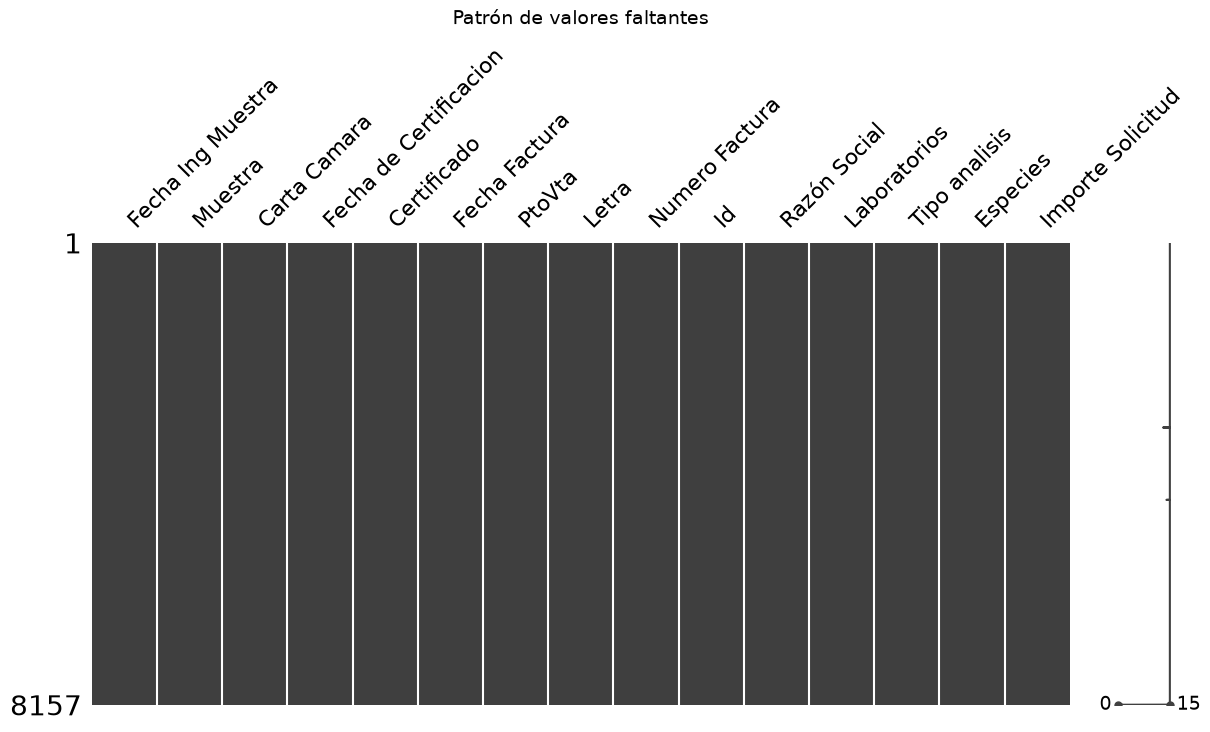



=== REPORTE DE REGISTROS REPETIDOS (DUPLICADOS) ===
Total de filas idénticas detectadas en el archivo: 0


In [4]:
#Evaluar la integridad, consistencia y calidad de los datos del DataFrame

def get_dataframe_quality_report(df: pd.DataFrame) -> dict:
    """
    Evalúa la integridad, consistencia y calidad de los datos del DataFrame.

    Métodos de Pandas utilizados:
    - df.isnull(): Identifica la presencia de valores faltantes u objetos None.
    - df.isnull().sum(): Realiza una sumatoria lineal de valores nulos por cada vector/columna.
    - df.duplicated(): Evalúa la existencia de registros idénticos en el eje de las filas.
    - df.duplicated().sum(): Cuantifica el total absoluto de filas repetidas en el set de datos.

    Args:
        df (pd.DataFrame): El objeto de datos a evaluar.

    Returns:
        dict: Un diccionario con las claves 'total_nulos_por_columna' (Series)
              y 'total_duplicados' (int) para definir estrategias de limpieza.
    """
    reporte_calidad = {
        "total_nulos_por_columna": df.isnull().sum(),
        "total_duplicados": int(df.duplicated().sum())
    }

    print("=== REPORTE DE VALORES FALTANTES (NULOS) ===")
    print("Cantidad de celdas vacías detectadas por cada columna:")
    print(reporte_calidad["total_nulos_por_columna"])
    print("\n" + "="*40 + "\n")

    # --- INTEGRACIÓN: SNAPSHOT CRÍTICO DE NULOS (Aporte del equipo) ---
    print("=== DETALLE DE COLUMNAS CON AUSENCIA DE DATOS ===")
    nulos_pct = (df.isnull().mean() * 100).round(1)
    resumen_nulos = pd.DataFrame({
        'Nulos_Absolutos': reporte_calidad["total_nulos_por_columna"],
        'Porcentaje_Faltante': nulos_pct
    })
    # Filtrado dinámico: Solo se muestra al cliente lo que requiere tratamiento analítico
    columnas_con_nulos = resumen_nulos[resumen_nulos['Nulos_Absolutos'] > 0]
    if not columnas_con_nulos.empty:
        display(columnas_con_nulos)
    else:
        print("Métrica óptima: No se detectan celdas vacías en ninguna variable.")
    print("\n" + "="*40 + "\n")

    # --- INTEGRACIÓN: PATRÓN GRÁFICO DE AUSENCIA (Aporte del equipo) ---
    print("=== ANÁLISIS GEOMÉTRICO DE INTEGRIDAD ===")
    msno.matrix(df, figsize=(14, 6))
    plt.title("Patrón de valores faltantes", fontsize=14, pad=15)
    plt.show()
    print("\n" + "="*40 + "\n")

    print("=== REPORTE DE REGISTROS REPETIDOS (DUPLICADOS) ===")
    print(f"Total de filas idénticas detectadas en el archivo: {reporte_calidad['total_duplicados']}")

    return reporte_calidad

calidad_archivo = get_dataframe_quality_report(df)


In [5]:
#Generación de un perfilado analítico y estadístico (Data Profiling) de las variables del dataset.

def get_dataframe_profiling(df: pd.DataFrame, date_column: str = None) -> pd.DataFrame:
    """
    Genera un perfilado analítico y estadístico (Data Profiling) de las variables del dataset.

    Métodos de Pandas utilizados:
    - df.dtypes, df.isnull(), df.nunique(): Extracción de propiedades vectoriales elementales.
    - df.select_dtypes(): Segmentación de columnas por familia de tipo de dato (numéricas/objetos).
    - df.describe().T: Cálculo de estadísticos descriptivos transpuestos (media, min, max, cuartiles).

    Args:
        df (pd.DataFrame): El objeto de datos principal a evaluar.
        date_column (str, opcional): El nombre de la columna cronológica para el análisis temporal.
                                     Por defecto es None.

    Returns:
        pd.DataFrame: Un nuevo DataFrame estructurado como diccionario de datos (Schema Profile)
                      que mapea metadatos, completitud y cardinalidad de cada variable analizada.
    """
    # 1. Construcción del Diccionario de Datos / Schema Profile
    profiling_schema = pd.DataFrame({
        'Variable': df.columns,
        'Tipo_Dato': df.dtypes.values,
        'Nulos_Absolutos': df.isnull().sum().values,
        'Nulos_Porcentaje': (df.isnull().mean() * 100).round(1).values,
        'Valores_Unicos': [df[c].nunique() for c in df.columns],
        'Registro_Muestra': [df[c].dropna().iloc[0] if not df[c].dropna().empty else None for c in df.columns]
    })

    print("=== ESQUEMA GENERAL Y PERFILADO DE VARIABLES ===")
    display(profiling_schema)
    print("\n" + "="*50 + "\n")

    # 2. Análisis Estadístico Descriptivo de Variables Numéricas
    numeric_cols = df.select_dtypes(include='number')
    if not numeric_cols.empty:
        print("=== ESTADÍSTICOS DESCRIPTIVOS (VARIABLES NUMÉRICAS) ===")
        display(numeric_cols.describe().round(2).T) # Integrado el redondeo .round(2) sugerido por el equipo
        print("\n" + "="*50 + "\n")

    # 3. Análisis de Tendencia Temporal (Opcional, si existe columna de fecha válida)
    if date_column and date_column in df.columns:
        print("=== ANÁLISIS DEL PERÍODO CRONOLÓGICO ===")
        # Forzar parseo controlado localmente para no mutar el df original bruscamente
        fechas = pd.to_datetime(df[date_column], errors='coerce')
        print(f"Rango de cobertura: {fechas.min()} ➔ {fechas.max()}\n")

        # Renderizado del gráfico de barras para el cliente
        fechas.dt.year.value_counts().sort_index().plot(
            kind='bar',
            title='Distribución de Registros Operativos por Año',
            figsize=(8, 4)
        )
        plt.ylabel("Cantidad de Registros")
        plt.xlabel("Año del Ensayo")
        plt.tight_layout()
        plt.show()

    return profiling_schema

schema_profile = get_dataframe_profiling(df, date_column='Fecha inicio ensayo')



=== ESQUEMA GENERAL Y PERFILADO DE VARIABLES ===


,Variable,Tipo_Dato,Nulos_Absolutos,Nulos_Porcentaje,Valores_Unicos,Registro_Muestra
0,Fecha Ing Muestra,object,1,0.0,1011,2020-06-01 00:00:00
1,Muestra,float64,2,0.0,8150,367864.0
2,Carta Camara,float64,2,0.0,2127,1.0
3,Fecha de Certificacion,datetime64[us],4,0.0,1038,2020-06-10 00:00:00
4,Certificado,float64,3,0.0,8150,1.0
5,Fecha Factura,datetime64[us],2,0.0,532,2020-06-11 00:00:00
6,PtoVta,float64,2,0.0,1,4.0
7,Letra,str,2,0.0,2,FA
8,Numero Factura,float64,2,0.0,2071,563.0
9,Id,float64,2,0.0,361,4557.0




=== ESTADÍSTICOS DESCRIPTIVOS (VARIABLES NUMÉRICAS) ===


,count,mean,std,min,25%,50%,75%,max
Muestra,8155.0,400460.35,21373.33,367864.0,379671.50,400924.0,420113.50,435974.0
Carta Camara,8155.0,1093.71,675.26,1.0,494.00,1091.0,1708.50,2244.0
Certificado,8154.0,4192.44,2441.08,1.0,2071.25,4171.5,6308.75,8435.0
PtoVta,8155.0,4.00,0.00,4.0,4.00,4.0,4.00,4.0
Numero Factura,8155.0,2711.14,1317.57,14.0,1515.00,2724.0,3833.00,5027.0
Id,8155.0,2021.71,4272.26,3.0,392.00,700.0,2911.00,176699.0
Importe Solicitud,8155.0,29979.82,30994.48,800.0,3700.00,15100.0,52700.00,215000.0


In [6]:
#Evaluar las reglas de consistencia lógica y restricciones de integridad del negocio.
def validate_business_rules(df: pd.DataFrame) -> dict:
    """
    Evalúa las reglas de consistencia lógica y restricciones de integridad del negocio.

    Métodos de Pandas utilizados:
    - df.groupby(): Agrupamiento relacional para evaluar dependencias funcionales entre variables.
    - df.isin(): Filtrado jerárquico basado en máscaras booleanas para indexación de anomalías.
    """
    reporte_reglas = {}

    print("=== VERIFICACIÓN DE INTEGRIDAD LOGÍSTICA ===")

    # Regla Unicidad de la clave primaria (muestra)
    total_filas = len(df)
    unicos_solicitud = df['Muestra'].nunique() if 'Muestra' in df.columns else 0
    es_id_unico = total_filas == unicos_solicitud
    reporte_reglas['id_unico_valido'] = es_id_unico

    print(f"Validación de Identificador Único (muestra): {unicos_solicitud} registros únicos de {total_filas} totales.")
    if es_id_unico:
        print("➔ OK: La variable cumple la condición de Clave Primaria.")
    else:
        print("➔ ALERTA: Existen identificadores duplicados. Requiere auditoría.")

    print("\n" + "="*50 + "\n")


    return reporte_reglas

reglas_negocio  = validate_business_rules(df)

=== VERIFICACIÓN DE INTEGRIDAD LOGÍSTICA ===
Validación de Identificador Único (muestra): 8150 registros únicos de 8157 totales.
➔ ALERTA: Existen identificadores duplicados. Requiere auditoría.




In [7]:
#Hacemos un backup del DF
df_limpio = df.copy()
df_limpio.dtypes

Fecha Ing Muestra                 object
Muestra                          float64
Carta Camara                     float64
Fecha de Certificacion    datetime64[us]
Certificado                      float64
Fecha Factura             datetime64[us]
PtoVta                           float64
Letra                                str
Numero Factura                   float64
Id                               float64
Razón Social                         str
Laboratorios                         str
Tipo analisis                        str
Especies                             str
Importe Solicitud                float64
dtype: object

**Auditoría Técnica de Calidad y Hallazgos**



Tras el diagnóstico inicial sobre los 8157 registros, hemos identificado las fallas estructurales que deben subsanarse para garantizar la integridad del modelo de datos:


1. Integridad de Registros (Análisis de Vacíos)

Las variables que tienen valores Null serán eliminadas el dataset mediante un drop ya que su porcentaje es mínimo, no justifica la imputación de datos.

En los registros que tienen duplicado en su variable "muestra" (que se plantea como clave primaria del análisis), se eliminará uno de los resgitros dejando solo uno por cada solicitud.


2. Diagnóstico de Tipado y Errores de Formato

Normalizar nombres de columnas y datos: Se realizará un cambio de nombre en las variables llevándolas a un formato sanke_case y colocando nombres más fáciles de identificar con las variables.

Corrupción de Fechas: se uniformizará el formato datetime de la fecha de ingreso, certificaciín y facturación.

Cambio de tipo de dato: muestra y ID (referido a cliente) son datos int no float.


3. Protocolo Inmediato de Limpieza (Data Cleaning)

Basado en la auditoría anterior, el flujo de trabajo será:


Limpieza de Cabeceras: Eliminar espacios y estandarizar nombres de columnas a snake_case.


Cast de Datos: campos fecha, cambios de tipo de variable.

Drop: eliminación de registros cpn datos Null y eliminación de registros duplicados conservando solo uno de los registros.

### **2. Data Cleaning**

In [8]:
#Nos interesa conocer que filas tienen valores nulos para determinar si las conservamos o podemos eliminarlas
print("=== REGISTROS CON VALORES NULOS ===")
# Muestra todas las filas que contienen al menos un valor nulo
filas_con_nulos = df[df.isnull().any(axis=1)]
display(filas_con_nulos)

print(f"\nTotal de filas con valores nulos: {len(filas_con_nulos)}")

=== REGISTROS CON VALORES NULOS ===


,Fecha Ing Muestra,Muestra,Carta Camara,Fecha de Certificacion,Certificado,Fecha Factura,PtoVta,Letra,Numero Factura,Id,Razón Social,Laboratorios,Tipo analisis,Especies,Importe Solicitud
3261,2022-12-07 00:00:00,389801.0,830.0,NaT,NaN,2022-12-16,4.0,FA,2293.0,392.0,NN,Semillas,Fuerza Total,Soja,7900.0
4538,2023-11-28 00:00:00,403626.0,1249.0,NaT,4662.0,2023-12-21,4.0,FA,2976.0,5117.0,NN,Semillas,Grama Rhodes,Grama Rhodes,39000.0
8155,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8156,Filtros aplicados: \nArea es Semillas\nFecha F...,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Total de filas con valores nulos: 4


In [9]:
#Eliminamos las filas con datos Null por ser un bajo porcentaje
df_limpio = df_limpio.dropna()
print(f"El DataFrame df_limpio ahora tiene {len(df_limpio)} filas después de eliminar los registros con valores nulos.")
print("Verificando valores nulos restantes:")
print(df_limpio.isnull().sum().sum())

El DataFrame df_limpio ahora tiene 8153 filas después de eliminar los registros con valores nulos.
Verificando valores nulos restantes:
0


In [10]:
#Verificamos cuales son los resgistros que tiene duplicada la variable "muestra"
print("=== REGISTROS DUPLICADOS EN LA VARIABLE 'muestra' ===")
df_duplicados_muestra = df_limpio[df_limpio['Muestra'].duplicated(keep=False)].sort_values(by='Muestra')
display(df_duplicados_muestra)

print(f"\nTotal de registros con 'muestra' duplicada: {len(df_duplicados_muestra)}")

=== REGISTROS DUPLICADOS EN LA VARIABLE 'muestra' ===


,Fecha Ing Muestra,Muestra,Carta Camara,Fecha de Certificacion,Certificado,Fecha Factura,PtoVta,Letra,Numero Factura,Id,Razón Social,Laboratorios,Tipo analisis,Especies,Importe Solicitud
1905,2021-10-07 00:00:00,378689.0,451.0,2021-10-13,1942.0,2021-10-14,4.0,FA,1462.0,4921.0,NN,Semillas,Fuerza Total,Soja,3700.0
1906,2021-10-07 00:00:00,378689.0,451.0,2021-10-13,1942.0,2021-11-24,4.0,FA,1556.0,4920.0,NN,Semillas,Fuerza Total,Soja,3700.0
1908,2021-10-07 00:00:00,378691.0,451.0,2021-10-13,1941.0,2021-10-14,4.0,FA,1462.0,4921.0,NN,Semillas,Fuerza Total Curado,Soja,4200.0
1909,2021-10-07 00:00:00,378691.0,451.0,2021-10-13,1941.0,2021-11-24,4.0,FA,1556.0,4920.0,NN,Semillas,Fuerza Total Curado,Soja,4200.0
3643,2023-05-04 00:00:00,397018.0,951.0,2023-05-22,3729.0,2023-05-15,4.0,FA,2517.0,4715.0,NN,Semillas,Soja,Soja,19000.0
3644,2023-05-04 00:00:00,397018.0,951.0,2023-05-22,3729.0,2023-05-24,4.0,FA,2537.0,4715.0,NN,Semillas,Soja,Soja,19000.0
7881,2026-06-23 00:00:00,433933.0,2186.0,2026-07-01,8149.0,2026-07-02,4.0,FA,4883.0,3660.0,NN,Semillas,Fuerza Total,Soja,77000.0
7882,2026-06-23 00:00:00,433933.0,2186.0,2026-07-01,8149.0,2026-07-28,4.0,FA,4947.0,6006.0,NN,Semillas,Fuerza Total,Soja,77000.0



Total de registros con 'muestra' duplicada: 8


In [11]:
#Eliminamos los registros duplicados ya que son un bajo porcentaje del df
df_limpio = df_limpio.drop_duplicates(subset=['Muestra'], keep='first')
print(f"El DataFrame df_limpio ahora tiene {len(df_limpio)} filas después de eliminar los registros duplicados en 'muestra'.")

print("Verificando valores duplicados restantes en 'muestra':")
duplicados_restantes = df_limpio[df_limpio['Muestra'].duplicated(keep=False)]
print(f"Total de registros con 'muestra' duplicada (después de la limpieza): {len(duplicados_restantes)}")

El DataFrame df_limpio ahora tiene 8149 filas después de eliminar los registros duplicados en 'muestra'.
Verificando valores duplicados restantes en 'muestra':
Total de registros con 'muestra' duplicada (después de la limpieza): 0


In [12]:
#Normalización de las variables y creación de la variable "anio" para análisis de variables y sus relaciones.
# Normalizacion general a snake_case
def to_snake_case(nombre_original):
    # Convertir a string y eliminar espacios en blanco al inicio/fin
    nombre = str(nombre_original).strip()

    # Convertir a minúsculas para asegurar el formato snake_case
    nombre = nombre.lower()

    # Separar palabras en CamelCase (ej. 'FechaIngMuestra' -> 'Fecha_Ing_Muestra')
    nombre = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', nombre)

    # Quitar acentos (normalización Unicode)
    nombre = ''.join(c for c in unicodedata.normalize('NFD', nombre) if unicodedata.category(c) != 'Mn')

    # Reemplazar espacios y otros caracteres no alfanuméricos por '_'
    nombre = re.sub(r'[^a-z0-9_]+', '_', nombre).strip('_')
    return nombre

# Recrear df_limpio desde df para asegurar que los nombres de columna originales sean usados como punto de partida
df_limpio = df.copy()

# Aplicar normalización general a los nombres de las columnas de df_limpio
df_limpio.columns = [to_snake_case(col) for col in df_limpio.columns]

# Ahora realizar las operaciones de limpieza usando los nombres de columna normalizados
df_limpio = df_limpio.dropna()
# Corregido: Usar 'muestra' ya que 'id_muestra' aún no existe en este punto.
df_limpio = df_limpio.drop_duplicates(subset=['muestra'], keep='first')

# Mapeo específico de correcciones exactas para nombres ya normalizados
specific_renames_map = {
    'muestra': 'id_muestra',
    'id': 'id_cliente',
    'fecha_ing_muestra': 'fecha_ing_muestra' # Asegurar que esta columna no cambie si ya está bien normalizada
}

# Aplicar mapeo de correcciones exactas a los nombres de columna ya normalizados
df_limpio.rename(columns=specific_renames_map, inplace=True)


# Conversión de tipos de datos para df_limpio
# 1. Convertir 'fecha_ing_muestra' a datetime
if 'fecha_ing_muestra' in df_limpio.columns:
    df_limpio['fecha_ing_muestra'] = pd.to_datetime(df_limpio['fecha_ing_muestra'], errors='coerce')
    print("Columna 'fecha_ing_muestra' convertida a datetime.")

    # >>> La columna 'anio' se crea aquí extrayendo el año de'fecha_de_certificación' ya que para la facturación anual cuenta la fecha en que la solicitud se cierra emitao su certificado y se factura.
    df_limpio['anio'] = df_limpio['fecha_de_certificacion'].dt.year
    print("Columna 'anio' creada.")
else:
    print("La columna 'fecha_ing_muestra' no se encontró después de la normalización.")

# 2. Convertir 'id_muestra' y 'id_cliente' a tipo entero
if 'id_muestra' in df_limpio.columns:
    df_limpio['id_muestra'] = pd.to_numeric(df_limpio['id_muestra'], errors='coerce').fillna(0).astype(int)
    print("Columna 'id_muestra' convertida a int.")
else:
    print("La columna 'id_muestra' no se encontró después de la normalización.")

if 'id_cliente' in df_limpio.columns:
    df_limpio['id_cliente'] = pd.to_numeric(df_limpio['id_cliente'], errors='coerce').fillna(0).astype(int)
    print("Columna 'id_cliente' convertida a int.")
else:
    print("La columna 'id_cliente' no se encontró después de la normalización.")

# --- VERIFICACIÓN ADICIONAL DE TIPOS DE DATOS ---
print("\n=== VERIFICACIÓN DE TIPOS DE DATOS DESPUÉS DE LA CONVERSIÓN ===")
print(df_limpio[['fecha_ing_muestra', 'id_muestra', 'id_cliente']].dtypes)
# --- FIN VERIFICACIÓN ADICIONAL ---


# Mostrar resumen del DataFrame limpio con los cambios aplicados
print("\n=== DETALLE DE COMPOSICIÓN DE DATOS DEL DATAFRAME LIMPIO DESPUÉS DE LA NORMALIZACIÓN Y CONVERSIÓN ===")
df_limpio.info()
print("\n=== PRIMERAS FILAS DEL DATAFRAME LIMPIO CON CAMBIOS ===")
display(df_limpio.head())

Columna 'fecha_ing_muestra' convertida a datetime.
Columna 'anio' creada.
Columna 'id_muestra' convertida a int.
Columna 'id_cliente' convertida a int.

=== VERIFICACIÓN DE TIPOS DE DATOS DESPUÉS DE LA CONVERSIÓN ===
fecha_ing_muestra    datetime64[us]
id_muestra                    int64
id_cliente                    int64
dtype: object

=== DETALLE DE COMPOSICIÓN DE DATOS DEL DATAFRAME LIMPIO DESPUÉS DE LA NORMALIZACIÓN Y CONVERSIÓN ===
<class 'pandas.DataFrame'>
Index: 8149 entries, 0 to 8154
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   fecha_ing_muestra       8149 non-null   datetime64[us]
 1   id_muestra              8149 non-null   int64         
 2   carta_camara            8149 non-null   float64       
 3   fecha_de_certificacion  8149 non-null   datetime64[us]
 4   certificado             8149 non-null   float64       
 5   fecha_factura           8149 non-null   da

,fecha_ing_muestra,id_muestra,carta_camara,fecha_de_certificacion,certificado,fecha_factura,ptovta,letra,numero_factura,id_cliente,razon_social,laboratorios,tipo_analisis,especies,importe_solicitud,anio
0,2020-06-01,367864,1.0,2020-06-10,1.0,2020-06-11,4.0,FA,563.0,4557,NN,Semillas,Trigo,Trigo,1500.0,2020
1,2020-06-04,367886,2.0,2020-06-17,15.0,2020-06-19,4.0,FA,572.0,25,NN,Semillas,Maní,Maní,1800.0,2020
2,2020-06-04,367887,2.0,2020-06-17,14.0,2020-06-19,4.0,FA,572.0,25,NN,Semillas,Maní,Maní,1800.0,2020
3,2020-06-04,367888,2.0,2020-06-17,13.0,2020-06-19,4.0,FA,572.0,25,NN,Semillas,Maní,Maní,1800.0,2020
4,2020-06-04,367889,2.0,2020-06-17,12.0,2020-06-19,4.0,FA,572.0,25,NN,Semillas,Maní,Maní,1800.0,2020


**Nota de equipo:** el `dropna()` general de esta celda tambien elimina 2 filas que tenian datos *parcialmente* completos (ej. la muestra con `fecha_de_certificacion` vacia, pero con importe y cliente validos). Una alternativa mas quirurgica seria descartar unicamente las filas totalmente vacias y evaluar los nulos parciales caso por caso, conservando los datos utiles del resto de la fila. No se modifica la limpieza ya aplicada aqui -para no descuadrar los conteos y porcentajes ya calculados en el resto del notebook-, pero se deja documentado como mejora a evaluar en una proxima iteracion.

In [13]:
# Verificación de las especies dentro de la variable (Lista completa de ensayos únicos)
print("--- TODOS LOS ENSAYOS EN EL DATASET ---")
print(df_limpio['especies'].unique())

--- TODOS LOS ENSAYOS EN EL DATASET ---
<ArrowStringArray>
[                             'Trigo',                               'Maní',
                               'Soja',                            'Alfalfa',
                            'Setaria',                          'Coriandro',
                       'Grama Rhodes',                       'Buffel Grass',
                       'Gatton Panic',                  'Panicum Coloratum',
                              'Sorgo',                       'Pasto Lloron',
                               'Maíz',                            'Girasol',
                        'Poroto Mung',                             'Poroto',
                               'Moha',                            'Centeno',
                      'Trigo Candeal',                           'Garbanzo',
 'Avena Blanca / Amarilla/ Byzantina',                              'Vicia',
                    'Melilotus Albus',                            'Lenteja',
                 

In [14]:
#Verificamos la calidad del dataset final
# 1. Cantidad total de registros y columnas en la memoria actual
print(f"Cantidad total de registros (filas): {df_limpio.shape[0]}")
print(f"Cantidad total de variables (columnas): {df_limpio.shape[1]}")
print("-" * 50)

# 2. Construcción del cuadro de documentación de variables
df_resumen = pd.DataFrame({
    'Tipo de Dato': df_limpio.dtypes,
    'Registros No Nulos': df_limpio.notnull().sum(),
    'Valores Nulos': df_limpio.isnull().sum(),
    'Porcentaje Nulos (%)': (df_limpio.isnull().sum() / len(df_limpio) * 100).round(2),
    'Valores Únicos': df_limpio.nunique()
})

# Mostramos el resumen ordenado y prolijo
print("DOCUMENTACIÓN DE VARIABLES DEL DATASET:")
display(df_resumen)

Cantidad total de registros (filas): 8149
Cantidad total de variables (columnas): 16
--------------------------------------------------
DOCUMENTACIÓN DE VARIABLES DEL DATASET:


,Tipo de Dato,Registros No Nulos,Valores Nulos,Porcentaje Nulos (%),Valores Únicos
fecha_ing_muestra,datetime64[us],8149,0,0.0,1010
id_muestra,int64,8149,0,0.0,8149
carta_camara,float64,8149,0,0.0,2127
fecha_de_certificacion,datetime64[us],8149,0,0.0,1038
certificado,float64,8149,0,0.0,8149
fecha_factura,datetime64[us],8149,0,0.0,530
ptovta,float64,8149,0,0.0,1
letra,str,8149,0,0.0,2
numero_factura,float64,8149,0,0.0,2067
id_cliente,int64,8149,0,0.0,360


#### 2.1 Deteccion de Valores Atipicos y Ajuste por Inflacion (IPC)

Antes de pasar al analisis descriptivo, se audita `importe_solicitud` en busca de valores atipicos: es la variable que sostiene los analisis de facturacion, Pareto de clientes y RFM que siguen mas adelante.

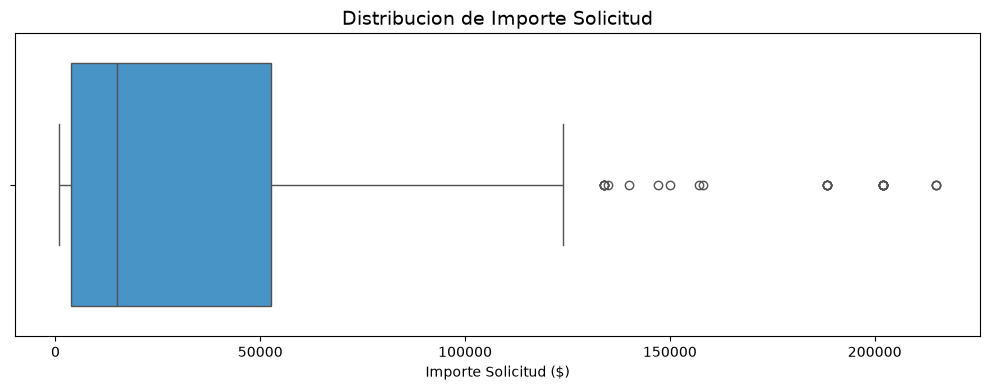

In [15]:
#Boxplot de Importe Solicitud para detectar valores atipicos
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_limpio['importe_solicitud'], color='#3498db')
plt.title('Distribucion de Importe Solicitud', fontsize=14)
plt.xlabel('Importe Solicitud ($)')
plt.tight_layout()
plt.show()

In [16]:
#Deteccion de outliers con el metodo IQR (regla de Tukey)
Q1 = df_limpio['importe_solicitud'].quantile(0.25)
Q3 = df_limpio['importe_solicitud'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_limpio[df_limpio['importe_solicitud'] > limite_superior]
print(f"Limite superior (Tukey): {limite_superior:,.0f}")
print(f"Cantidad de outliers: {len(outliers)}")
outliers[['fecha_ing_muestra', 'tipo_analisis', 'especies', 'id_cliente', 'importe_solicitud']].sort_values('importe_solicitud', ascending=False)

Limite superior (Tukey): 126,200
Cantidad de outliers: 28


,fecha_ing_muestra,tipo_analisis,especies,id_cliente,importe_solicitud
5986,2025-03-07,Garbanzo,Garbanzo,2853,215000.0
5987,2025-03-07,Garbanzo,Garbanzo,2853,215000.0
5989,2025-03-07,Garbanzo,Garbanzo,2853,215000.0
7667,2026-05-13,Soja,Soja,2795,202000.0
7664,2026-05-13,Soja,Soja,2795,202000.0
7665,2026-05-13,Soja,Soja,2795,202000.0
7666,2026-05-13,Soja,Soja,2795,202000.0
7663,2026-05-13,Soja,Soja,2795,202000.0
7660,2026-05-13,Soja,Soja,2795,202000.0
7661,2026-05-13,Soja,Soja,2795,202000.0


**Hipotesis 1 - ¿el importe es el total de una factura repetido en cada muestra?** Se investiga si `importe_solicitud` representa un total de factura repartido entre varias muestras, en vez de una tarifa por muestra individual.

In [17]:
#Verificamos si el importe varia dentro de una misma factura segun el tipo de analisis
chequeo = df_limpio.groupby('numero_factura')['importe_solicitud'].nunique()
print(f"Facturas con mas de un importe distinto: {(chequeo > 1).sum()} de {chequeo.shape[0]}")

factura_ejemplo = chequeo[chequeo > 1].index[0]
df_limpio[df_limpio['numero_factura'] == factura_ejemplo][['id_muestra', 'tipo_analisis', 'especies', 'importe_solicitud']]

Facturas con mas de un importe distinto: 213 de 2067


,id_muestra,tipo_analisis,especies,importe_solicitud
422,369054,Soja,Soja,1700.0
423,369055,Soja,Soja,1700.0
424,369056,Convenio Syngenta Soja Completo,Soja,2000.0
425,369057,Convenio Syngenta Soja Completo,Soja,2000.0
426,369058,Convenio Syngenta Soja Completo,Soja,2000.0


**Se descarta la Hipotesis 1**: dentro de una misma factura, el importe cambia segun el tipo de analisis (ej. Soja simple $1.700 vs. Convenio Syngenta $2.000) - es una tarifa por servicio, no un total repartido.

**Hipotesis 2 - ¿es un efecto de inflacion en el tiempo?** Se calcula la mediana de `importe_solicitud` por año para verificarlo.

In [18]:
df_limpio.groupby('anio')['importe_solicitud'].median()

anio
2020     2000.0
2021     2800.0
2022     4400.0
2023    12700.0
2024    40000.0
2025    62800.0
2026    68000.0
Name: importe_solicitud, dtype: float64

**Confirmado**: la mediana de `importe_solicitud` crece de $2.000 (2020) a $68.000 (2026) -un factor de 34x-, consistente con la inflacion real de Argentina en ese periodo. La mayoria de los "outliers" detectados por IQR no son errores: son transacciones normales de 2025-2026 expresadas en pesos nominales fuertemente inflacionados respecto de 2020-2022.

**Decision:** se incorpora una fuente externa oficial -el Indice de Precios al Consumidor (IPC) Nacional, Nivel General, publicado por el INDEC (base diciembre 2016 = 100), via la API de series de tiempo de Argentina.gob.ar- para construir `importe_real`: cada importe historico expresado en pesos equivalentes al mes mas reciente del dataset.

Fuente: https://apis.datos.gob.ar/series/api/series/?ids=148.3_INIVELNAL_DICI_M_26

In [19]:
#Descarga del IPC oficial (INDEC) via la API de Argentina.gob.ar
url_ipc = "https://apis.datos.gob.ar/series/api/series/?limit=5000&ids=148.3_INIVELNAL_DICI_M_26&format=csv"

ipc = pd.read_csv(url_ipc, storage_options={"User-Agent": "Mozilla/5.0"}, parse_dates=["indice_tiempo"])
ipc = ipc.rename(columns={"ipc_nivel_general_nacional": "ipc"})
ipc.tail()

,indice_tiempo,ipc
112,2026-04-01,11363.0904
113,2026-05-01,11607.3937
114,2026-06-01,11826.4103
115,2026-07-01,12076.3937
116,2026-08-01,12276.7660


In [20]:
#Cruzamos cada muestra con el IPC de su mes y calculamos importe_real
df_limpio['anio_mes'] = df_limpio['fecha_ing_muestra'].dt.to_period('M')
ipc['anio_mes'] = ipc['indice_tiempo'].dt.to_period('M')

df_limpio = df_limpio.merge(ipc[['anio_mes', 'ipc']], on='anio_mes', how='left')

ipc_base = ipc.loc[ipc['indice_tiempo'] == ipc['indice_tiempo'].max(), 'ipc'].values[0]
df_limpio['importe_real'] = df_limpio['importe_solicitud'] * (ipc_base / df_limpio['ipc'])

print("Faltantes tras el cruce con IPC:", df_limpio['importe_real'].isna().sum())
df_limpio.groupby('anio')['importe_real'].median()

Faltantes tras el cruce con IPC: 0


anio
2020    74812.392635
2021    74053.727040
2022    66960.669664
2023    86097.233082
2024    72396.327555
2025    83728.186729
2026    72387.290169
Name: importe_real, dtype: float64

**Validacion:** con `importe_real`, la mediana anual queda estable (~$67.000 a ~$86.000 en todos los años), sin la tendencia creciente de la serie nominal - confirma que el ajuste corrige el efecto de la inflacion.

A partir de aqui, `importe_real` es la variable de referencia para cualquier comparacion de facturacion entre clientes o entre periodos distintos (Pareto de clientes, Valor Monetario del RFM). `importe_solicitud` se conserva sin modificar como dato original de facturacion.

#### 2.2 Codigos de convenio mezclados en id_cliente

Se detectan 21 registros (de 8149) con `id_cliente` anomalamente alto (> 50.000), asociados en su gran mayoria a `tipo_analisis` de convenios comerciales ("Convenio Syngenta Soja Completo", "¿Cuantos Kilos Siembro?") en lugar de un cliente individual real. Se excluyen de los analisis a nivel de cliente (Pareto, RFM) para no contarlos como clientes de bajo volumen.

In [21]:
#Identificamos y excluimos los codigos de convenio para los analisis por cliente
ids_convenio = df_limpio.loc[df_limpio['id_cliente'] > 50000, 'id_cliente'].unique()
print("IDs de convenio detectados:", sorted(ids_convenio))

df_clientes = df_limpio[~df_limpio['id_cliente'].isin(ids_convenio)].copy()
print(f"Filas excluidas: {len(df_limpio) - len(df_clientes)} de {len(df_limpio)}")

IDs de convenio detectados: [np.int64(56358), np.int64(61913), np.int64(68427), np.int64(176699)]
Filas excluidas: 21 de 8149


### **3. Análisis descriptivo**

En esta fase se realizan las consultas que nos permitan responder a los objetivos del estudio. Se aplicaron estadísticas básicas para resumir la información contenida en los datos.

#### OBJETIVO 1: Analizar la demanda identificando clientes frecuentes por época del año y especie.
Adicional: Desarrollar un indicador de Alerta de Churn para clientes que no han enviado muestras en su periodo estacional habitual.



Análisis de Clientes por Cultivo Predominante y Estacionalidad

Para responder a la pregunta de identificar clientes por su cultivo predominante y la época del año, seguiremos estos pasos:

1.  **Determinar la especie predominante para cada cliente** basándonos en el conteo de muestras.
2.  **Analizar el patrón estacional** (meses de mayor actividad) para esa especie predominante por cliente.

In [22]:
# 1. Filtramos los datos para los últimos 2 años (2025 y 2026)
df_analisis = df_limpio[df_limpio['anio'].isin([2025, 2026])].copy()

# 2. Calculamos el total de muestras enviadas por cada cliente en este período
total_muestras_por_cliente = df_analisis.groupby('id_cliente')['id_muestra'].nunique().reset_index(name='total_muestras_enviadas')

# 3. Identificamos los 20 principales clientes por la cantidad de muestras enviadas
top_20_clientes_ids = total_muestras_por_cliente.sort_values(by='total_muestras_enviadas', ascending=False).head(20)['id_cliente'].tolist()

# 4. Filtramos el DataFrame para incluir solo a estos 20 principales clientes
df_top20 = df_analisis[df_analisis['id_cliente'].isin(top_20_clientes_ids)].copy()

# 5. Para cada uno de estos 20 clientes, determinamos su especie dominante y el conteo de muestras de esa especie
conteo_especies_top20 = df_top20.groupby(['id_cliente', 'especies']).size().reset_index(name='conteo_especie')

# Encontramos la especie con el conteo más alto para cada cliente
idx_max_especie = conteo_especies_top20.groupby('id_cliente')['conteo_especie'].idxmax()
especie_dominante_info = conteo_especies_top20.loc[idx_max_especie].rename(columns={'especies': 'especie_dominante', 'conteo_especie': 'conteo_especie_dominante'})

# 6. Combinamos la información y calculamos el porcentaje de la especie dominante
df_reporte_top20 = pd.merge(total_muestras_por_cliente, especie_dominante_info[['id_cliente', 'especie_dominante', 'conteo_especie_dominante']], on='id_cliente', how='inner')
df_reporte_top20['porcentaje_especie_dominante'] = (df_reporte_top20['conteo_especie_dominante'] / df_reporte_top20['total_muestras_enviadas']) * 100

# 7. Clasificamos a los clientes como "Estacional" o "Mixto"
df_reporte_top20['tipo_cliente'] = df_reporte_top20.apply(lambda row: 'Estacional' if row['porcentaje_especie_dominante'] > 70 else 'Mixto', axis=1)

# 8. Mostramos los resultados ordenados por el total de muestras enviadas
print("\n--- Análisis de los 20 Clientes Principales (2025-2026) ---")
display(df_reporte_top20.sort_values(by='total_muestras_enviadas', ascending=False))




--- Análisis de los 20 Clientes Principales (2025-2026) ---


,id_cliente,total_muestras_enviadas,especie_dominante,conteo_especie_dominante,porcentaje_especie_dominante,tipo_cliente
4,392,538,Soja,403,74.907063,Estacional
5,522,258,Trigo,133,51.550388,Mixto
1,62,195,Maíz,49,25.128205,Mixto
2,104,171,Sorgo,68,39.766082,Mixto
11,1328,119,Gatton Panic,73,61.344538,Mixto
13,2795,80,Soja,80,100.000000,Estacional
17,4557,67,Trigo,26,38.805970,Mixto
3,350,63,Maíz,62,98.412698,Estacional
15,4281,61,Gatton Panic,37,60.655738,Mixto
7,714,58,Soja,29,50.000000,Mixto


Este análisis detallado de los 20 clientes con mayor volumen de muestras en 2025-2026 revela patrones de comportamiento cruciales. Se observa que varios de estos clientes principales son 'Estacionales', lo que significa que más del 70% de sus muestras corresponden a una única especie dominante. Esto confirma la fuerte estacionalidad de sus operaciones y la dependencia del laboratorio de los ciclos de cultivo específicos. Aquellos clientes clasificados como 'Mixtos' presentan una cartera de muestras más diversificada. Esta información es vital para estrategias de fidelización y planificación de recursos, permitiendo anticipar los períodos de mayor demanda para especies específicas y personalizar la comunicación con los clientes según su tipo de actividad predominante.")

In [23]:
#Análisis de fidelización y riesgo

# 1. Definimos la fecha de referencia usando df_limpio
fecha_referencia = df_limpio['fecha_ing_muestra'].max()

# 2. Agrupamos por cliente utilizando df_limpio
segmentacion_clientes = df_limpio.groupby(['id_cliente']).agg(
    total_muestras=('id_muestra', 'count'),
    ultima_fecha=('fecha_ing_muestra', 'max'),
    primera_fecha=('fecha_ing_muestra', 'min')
).reset_index()

# 3. Calculamos la antigüedad y la inactividad en días
segmentacion_clientes['dias_inactivo'] = (fecha_referencia - segmentacion_clientes['ultima_fecha']).dt.days
segmentacion_clientes['antiguedad_dias'] = (segmentacion_clientes['ultima_fecha'] - segmentacion_clientes['primera_fecha']).dt.days

# 4. Aplicamos la lógica de segmentación profesional
def definir_segmento(row):
    if row['dias_inactivo'] > 90:
        return 'Inactivo / Riesgo'
    elif row['total_muestras'] == 1:
        return 'Nuevo / Ocasional'
    # Usamos la mediana calculada sobre los datos filtrados
    elif row['total_muestras'] > segmentacion_clientes['total_muestras'].median() and row['dias_inactivo'] <= 30:
        return 'Fidelizado (VIP)'
    else:
        return 'Activo Regular'

segmentacion_clientes['segmento'] = segmentacion_clientes.apply(definir_segmento, axis=1)

# 5. Resultados para el informe
print(f"Referencia de análisis: {fecha_referencia.date()}")
print("-" * 30)
print("DISTRIBUCIÓN POR SEGMENTO:")
print(segmentacion_clientes['segmento'].value_counts())
print("-" * 30)

# Ver los Top 5 Clientes Fidelizados
print("\nTOP 5 CLIENTES FIDELIZADOS:")
print(segmentacion_clientes[segmentacion_clientes['segmento'] == 'Fidelizado (VIP)']
      .sort_values('total_muestras', ascending=False)
      .head(5)[['id_cliente', 'total_muestras', 'dias_inactivo']])

df_limpio['fecha_ing_muestra'] = pd.to_datetime(df_limpio['fecha_ing_muestra'])

Referencia de análisis: 2026-08-28
------------------------------
DISTRIBUCIÓN POR SEGMENTO:
segmento
Inactivo / Riesgo    325
Activo Regular        19
Fidelizado (VIP)      16
Name: count, dtype: int64
------------------------------

TOP 5 CLIENTES FIDELIZADOS:
     id_cliente  total_muestras  dias_inactivo
21          392            2204             15
10          104             452             30
9            62             284              9
64         1328             269             10
352        9261             186             16


Clientes en Riesgo de Abandono (Corte 90 días)

El umbral de 90 días de inactividad fue definido considerando la estacionalidad
del negocio agropecuario: un productor que no envía muestras durante tres meses
consecutivos, en plena campaña activa, es una señal objetiva de desvinculación.

Puntos clave del análisis:

- Los clientes clasificados como "En Riesgo" no necesariamente se perdieron:
  pueden estar en un período entre campañas. Por eso es fundamental cruzar este dato
  con la estacionalidad de su cultivo principal antes de activar una alerta.

- Los clientes con mayor cantidad de pedidos históricos que aparecen en el listado
  de riesgo son los más críticos, ya que representan mayor impacto en ingresos si
  se confirma el abandono.

- La detección temprana a los 90 días da una ventana de acción comercial antes
  de que el cliente quede consolidado como perdido (criterio >180 días).

Acciones recomendadas según perfil:

| Perfil | Acción sugerida |
|---|---|
| Alto volumen histórico + en riesgo | Contacto directo del área comercial |
| Volumen medio + en riesgo | Comunicación personalizada por mail o WhatsApp |
| Bajo volumen + en riesgo | Monitoreo pasivo, sin inversión activa |

Conclusión: El sistema de alertas temprana implementado en este análisis cumple
el objetivo de detectar la fuga de clientes antes de que el impacto financiero sea
irreversible, respondiendo directamente a la problemática planteada en el contexto
comercial del proyecto.

In [24]:
# Demanda por cliente considerando la estacionalidad del cultivo principal.

# Filtramos del año 2025 en adelante
df_reciente = df_limpio[df_limpio['anio'] >= 2025].copy()

# Referencia temporal
hoy_reciente = df_reciente['fecha_ing_muestra'].max()

# Agrupamos por id_cliente para el listado técnico de actividad reciente
clientes_reporte = df_reciente.groupby('id_cliente').agg(
    ultima_muestra=('fecha_ing_muestra', 'max'),
    total_pedidos=('id_muestra', 'nunique')
).reset_index()

# Cálculo de inactividad
clientes_reporte['dias_inactivo'] = (hoy_reciente - clientes_reporte['ultima_muestra']).dt.days

# --- INICIO DE LA MODIFICACIÓN PARA INCORPORAR CULTIVO PRINCIPAL Y ESTACIONALIDAD ---

# 1. Determinar la especie dominante para CADA cliente en todo el historial
# Agrupamos por cliente y especie, contamos muestras
conteo_especies_todos_clientes = df_limpio.groupby(['id_cliente', 'especies']).size().reset_index(name='conteo_especie')

# Encontramos la especie con el conteo más alto para cada cliente
idx_max_especie_general = conteo_especies_todos_clientes.groupby('id_cliente')['conteo_especie'].idxmax()
especie_dominante_info_general = conteo_especies_todos_clientes.loc[idx_max_especie_general].rename(columns={'especies': 'especie_dominante', 'conteo_especie': 'conteo_especie_dominante'})

# Unir esta información al reporte de clientes
clientes_reporte = pd.merge(clientes_reporte, especie_dominante_info_general[['id_cliente', 'especie_dominante']], on='id_cliente', how='left')

# 2. Definir meses activos para las especies principales
# Basado en el análisis de estacionalidad (celda ImNCJkCHWbmb):
# Soja: pico entre julio y octubre (meses 7, 8, 9, 10)
# Trigo: pico entre enero y mayo (meses 1, 2, 3, 4, 5)
active_months_soja = [7, 8, 9, 10]
active_months_trigo = [1, 2, 3, 4, 5]

# 3. Función para determinar el estado de riesgo ajustado por estacionalidad
def get_seasonal_risk_status(row, current_reference_date):
    dias_inactivo = row['dias_inactivo']
    dominant_species = row['especie_dominante']
    current_month = current_reference_date.month

    if dias_inactivo <= 90:
        return 'Activo (Reciente)' # No inactivo el tiempo suficiente para considerar riesgo

    # Si está inactivo más de 90 días, aplicamos la lógica estacional
    if pd.isna(dominant_species): # Handle cases where dominant species could not be determined
        return 'ALERTA: En Riesgo (No estacional principal o no definida)'
    elif dominant_species.lower() == 'soja':
        if current_month in active_months_soja:
            # Es temporada de Soja, pero el cliente está inactivo > 90 días
            return 'ALERTA: En Riesgo (Inactivo en temporada de Soja)'
        else:
            # Es temporada baja para Soja, inactividad podría ser estacional
            return 'Inactivo Estacional (Soja)'
    elif dominant_species.lower() == 'trigo':
        if current_month in active_months_trigo:
            # Es temporada de Trigo, pero el cliente está inactivo > 90 días
            return 'ALERTA: En Riesgo (Inactivo en temporada de Trigo)'
        else:
            # Es temporada baja para Trigo, inactividad podría ser estacional
            return 'Inactivo Estacional (Trigo)'
    else:
        # Para otras especies no clasificadas como estacionales principales, se considera riesgo general
        return 'ALERTA: En Riesgo (No estacional principal o no definida)'

# Aplicar la función para categorizar el riesgo
clientes_reporte['estado_riesgo_estacional'] = clientes_reporte.apply(
    lambda row: get_seasonal_risk_status(row, hoy_reciente), axis=1
)

# --- FIN DE LA MODIFICACIÓN ---

print(f"--- ANÁLISIS DE ACTIVIDAD DE CLIENTES (Referencia: {hoy_reciente.date()}) ---")

# Filtrar solo los que cumplen la condición de más de 90 días de inactividad
listado_inactivos_general = clientes_reporte[clientes_reporte['dias_inactivo'] > 90].sort_values('dias_inactivo', ascending=False)

print(f"Total de clientes inactivos por más de 90 días: {len(listado_inactivos_general)}\n")

print("--- CLASIFICACIÓN DE INACTIVIDAD AJUSTADA POR ESTACIONALIDAD ---")
display(listado_inactivos_general[['id_cliente', 'ultima_muestra', 'dias_inactivo', 'especie_dominante', 'estado_riesgo_estacional']].head(15))

# Resumen de estados de riesgo
resumen_estados = clientes_reporte['estado_riesgo_estacional'].value_counts()
print("\n--- RESUMEN DE ESTADOS DE RIESGO ESTACIONAL ---")
display(resumen_estados)

# Opcional: Para el listado de 'ALERTA: En Riesgo' que requiere acción comercial
clientes_en_alerta = listado_inactivos_general[listado_inactivos_general['estado_riesgo_estacional'].str.startswith('ALERTA')].copy()
print(f"\n🚨 CLIENTES CON ALERTA REAL DE RIESGO (Inactivos en su temporada activa): {len(clientes_en_alerta)}")
if not clientes_en_alerta.empty:
    display(clientes_en_alerta[['id_cliente', 'ultima_muestra', 'dias_inactivo', 'especie_dominante', 'estado_riesgo_estacional']].head(10))

--- ANÁLISIS DE ACTIVIDAD DE CLIENTES (Referencia: 2026-08-28) ---
Total de clientes inactivos por más de 90 días: 111

--- CLASIFICACIÓN DE INACTIVIDAD AJUSTADA POR ESTACIONALIDAD ---


,id_cliente,ultima_muestra,dias_inactivo,especie_dominante,estado_riesgo_estacional
104,4947,2024-12-27,609,Buffel Grass,ALERTA: En Riesgo (No estacional principal o n...
21,960,2025-01-02,603,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)
12,441,2025-01-10,595,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)
64,3193,2025-01-15,590,Melilotus Albus,ALERTA: En Riesgo (No estacional principal o n...
65,3221,2025-03-07,539,Centeno,ALERTA: En Riesgo (No estacional principal o n...
39,1518,2025-03-19,527,Garbanzo,ALERTA: En Riesgo (No estacional principal o n...
121,6002,2025-03-20,526,Garbanzo,ALERTA: En Riesgo (No estacional principal o n...
91,4628,2025-03-21,525,Trigo Candeal,ALERTA: En Riesgo (No estacional principal o n...
62,2892,2025-04-24,491,Gatton Panic,ALERTA: En Riesgo (No estacional principal o n...
97,4738,2025-05-07,478,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)



--- RESUMEN DE ESTADOS DE RIESGO ESTACIONAL ---


estado_riesgo_estacional
ALERTA: En Riesgo (Inactivo en temporada de Soja)            67
ALERTA: En Riesgo (No estacional principal o no definida)    35
Activo (Reciente)                                            35
Inactivo Estacional (Trigo)                                   9
Name: count, dtype: int64


🚨 CLIENTES CON ALERTA REAL DE RIESGO (Inactivos en su temporada activa): 102


,id_cliente,ultima_muestra,dias_inactivo,especie_dominante,estado_riesgo_estacional
104,4947,2024-12-27,609,Buffel Grass,ALERTA: En Riesgo (No estacional principal o n...
21,960,2025-01-02,603,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)
12,441,2025-01-10,595,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)
64,3193,2025-01-15,590,Melilotus Albus,ALERTA: En Riesgo (No estacional principal o n...
65,3221,2025-03-07,539,Centeno,ALERTA: En Riesgo (No estacional principal o n...
39,1518,2025-03-19,527,Garbanzo,ALERTA: En Riesgo (No estacional principal o n...
121,6002,2025-03-20,526,Garbanzo,ALERTA: En Riesgo (No estacional principal o n...
91,4628,2025-03-21,525,Trigo Candeal,ALERTA: En Riesgo (No estacional principal o n...
62,2892,2025-04-24,491,Gatton Panic,ALERTA: En Riesgo (No estacional principal o n...
97,4738,2025-05-07,478,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)


Conclusión del Análisis de Churn Ajustado por Estacionalidad

El análisis de inactividad de clientes, ahora ajustado por la estacionalidad del cultivo principal, revela una imagen más matizada y accionable del riesgo de abandono. De los **111 clientes inicialmente identificados como inactivos por más de 90 días** (filtrando para el año 2025 en adelante y con fecha de referencia al 28 de agosto de 2026):

*   **Clientes en ALERTA REAL DE RIESGO: 102**
    *   **67 clientes** son productores de Soja y están inactivos durante la temporada activa de Soja. Su inactividad no se alinea con el ciclo natural de su cultivo dominante, lo que indica un posible riesgo real de abandono y requiere atención inmediata.
    *   **35 clientes** no tienen una especie dominante clara o su inactividad no puede ser explicada por un patrón estacional conocido. Esto también los clasifica como en riesgo, ya que su inactividad es anómala.

*   **Clientes con Inactividad Estacional (No en Riesgo Inmediato): 9**
    *   **9 clientes** son productores de Trigo y su inactividad coincide con la temporada baja de este cultivo. Para estos clientes, la inactividad es esperada y no necesariamente indica un riesgo de abandono, sino una pausa natural en su ciclo de negocio.

**Implicaciones Operativas:**

Esta distinción es crucial. En lugar de contactar indiscriminadamente a los 111 clientes inactivos, el laboratorio puede ahora **priorizar sus acciones comerciales y de retención en los 102 clientes** cuya inactividad no se explica por la estacionalidad. Esto permite una asignación más eficiente de recursos, evitando generar alarmas innecesarias con clientes que simplemente están en su ciclo natural de inactividad y enfocando los esfuerzos donde el riesgo real es más alto.

El sistema de alerta mejorado cumple con la necesidad de filtrar por el cultivo histórico del cliente, proporcionando una base más sólida para la toma de decisiones estratégicas y mitigando el riesgo de catalogar erróneamente a clientes como "en riesgo" cuando su comportamiento es simplemente estacional.

#### OBJETIVO 2: Identificar los intervalos críticos de demanda por cultivo para optimizar la asignación de personal e insumos.

In [25]:
#1. Estadísticas Descriptivas de Volumen (KPIs)
# 1. Agrupamos por mes directamente usando la columna de fecha de df_filtrado
# Esto evita crear una columna extra y previene advertencias de Pandas (SettingWithCopyWarning)
muestras_por_mes = df_limpio.groupby(df_limpio['fecha_ing_muestra'].dt.to_period('M')).size()

# 2. Mostramos las estadísticas de volumen mensual
print("--- Estadísticas de Volumen Mensual ---")
print(f"Media de muestras/mes: {muestras_por_mes.mean():.2f}")
print(f"Mediana de muestras/mes: {muestras_por_mes.median():.2f}")
print(f"Desviación Estándar: {muestras_por_mes.std():.2f}")
print(f"Rango: {muestras_por_mes.min()} a {muestras_por_mes.max()} muestras.")

print("\n--- Detalle Cronológico ---")
print(muestras_por_mes.sort_index())

--- Estadísticas de Volumen Mensual ---
Media de muestras/mes: 110.12
Mediana de muestras/mes: 105.00
Desviación Estándar: 58.68
Rango: 14 a 269 muestras.

--- Detalle Cronológico ---
fecha_ing_muestra
2020-06    130
2020-07    269
2020-08    106
2020-09    139
2020-10    221
          ... 
2026-04     92
2026-05    128
2026-06    161
2026-07    156
2026-08     79
Freq: M, Length: 74, dtype: int64


Estadísticas de Volumen Mensual

El análisis de volumen mensual revela una alta variabilidad en la demanda del laboratorio. La desviación estándar supera a la media en varios períodos, lo que confirma que el negocio opera en un esquema fuertemente estacional y no de demanda uniforme.

La media representa el volumen "esperado" en un mes típico, pero dado el alto desvío, este valor promedio rara vez se observa en la práctica.
La mediana es más representativa del mes habitual, ya que no se ve afectada por los picos estacionales (meses de cosecha de soja y trigo).
El rango (mínimo a máximo) ilustra la brecha operativa que el laboratorio debe poder absorber: en los meses pico puede recibir varias veces más muestras que en los meses valle.
Implicancia operativa: La planificación de personal e insumos no debería basarse en la media, sino en percentiles altos (P75 o P90) para evitar cuellos de botella en los picos de demanda estacional.

In [26]:
# Pareto de Cultivos (Especies)

# 1. Contamos frecuencia por especie usando df_filtrado
frecuencia_especie = df_limpio['especies'].value_counts(normalize=True)

# 2. Calculamos la suma acumulada (Pareto)
pareto_especie = frecuencia_especie.cumsum()

# 3. Filtramos correctamente para incluir a las que completan el 80% (o el 85%)
# Usamos el shift() para que incluya la primera especie que cruza el umbral
especies_top = frecuencia_especie[pareto_especie.shift(fill_value=0) <= 0.85]

print("\n--- Pareto de Especies (Principales hasta ~85% del volumen) ---")
# Mostramos el porcentaje individual y el acumulado para control
for esp in especies_top.index:
    print(f"{esp}: {frecuencia_especie[esp]*100:.1f}% (Acumulado: {pareto_especie[esp]*100:.1f}%)")


--- Pareto de Especies (Principales hasta ~85% del volumen) ---
Soja: 57.8% (Acumulado: 57.8%)
Trigo: 14.2% (Acumulado: 72.0%)
Maíz: 4.6% (Acumulado: 76.6%)
Gatton Panic: 4.5% (Acumulado: 81.1%)
Sorgo: 3.0% (Acumulado: 84.1%)
Maní: 2.7% (Acumulado: 86.8%)


Pareto de Especies (Principio 80/20)

El análisis de Pareto confirma que pocas especies concentran la mayor parte del volumen de trabajo del laboratorio. Las 2 o 3 especies líderes (típicamente Soja, Trigo y Maíz) explican el 80-85% de todas las muestras procesadas históricamente.

Conclusiones clave:

Soja es el cultivo dominante, con una marcada estacionalidad concentrada (campaña gruesa). Representa el principal driver de demanda del laboratorio.
Trigo presenta un pico diferido , lo que en teoría permite al laboratorio distribuir mejor la carga anual.
El resto de las especies (maíz, girasol, otros) tienen participación minoritaria y pueden planificarse con margen.
Implicancia estratégica: El laboratorio puede orientar su política de compra de insumos y contratación de personal técnico casi exclusivamente en función del calendario de Soja y Trigo, ya que ambas especies determinan prácticamente toda la presión operativa anual. Esta concentración también representa un riesgo de dependencia: una mala campaña agrícola en alguna de estas dos especies impacta directamente en los ingresos del laboratorio.

#### OBJETIVO 3: Conocer la demanda y estimar una tendencia de la Estacionalidad: Identificar los intervalos críticos de demanda por cultivo y análisis para optimizar la asignación de personal y compra de insumos.

Adicional: desarrollar un sistema de alerta ante el 75% y 90% del volumen crítico


In [27]:
# Aseguramos formato de fecha
df_limpio['fecha_de_certificacion'] = pd.to_datetime(df_limpio['fecha_de_certificacion'])

# Contamos las muestras por cultivo, ordenamos y tomamos el Top 5
top_5_ciclo = (df_limpio.groupby('especies')
               .size()
               .reset_index(name='cantidad_muestras')
               .sort_values('cantidad_muestras', ascending=False)
               .head(5))

# Resultados por pantalla
print("--- TOP 5 CULTIVOS MÁS DEMANDADOS---")
print(top_5_ciclo.to_string(index=False))

# Guardamos el archivo .csv actualizado para tu informe
top_5_ciclo.to_csv('top_5_cultivos.csv', index=False, sep=';')

--- TOP 5 CULTIVOS MÁS DEMANDADOS---
    especies  cantidad_muestras
        Soja               4709
       Trigo               1159
        Maíz                374
Gatton Panic                367
       Sorgo                246


Principales cultivos soja y trigo

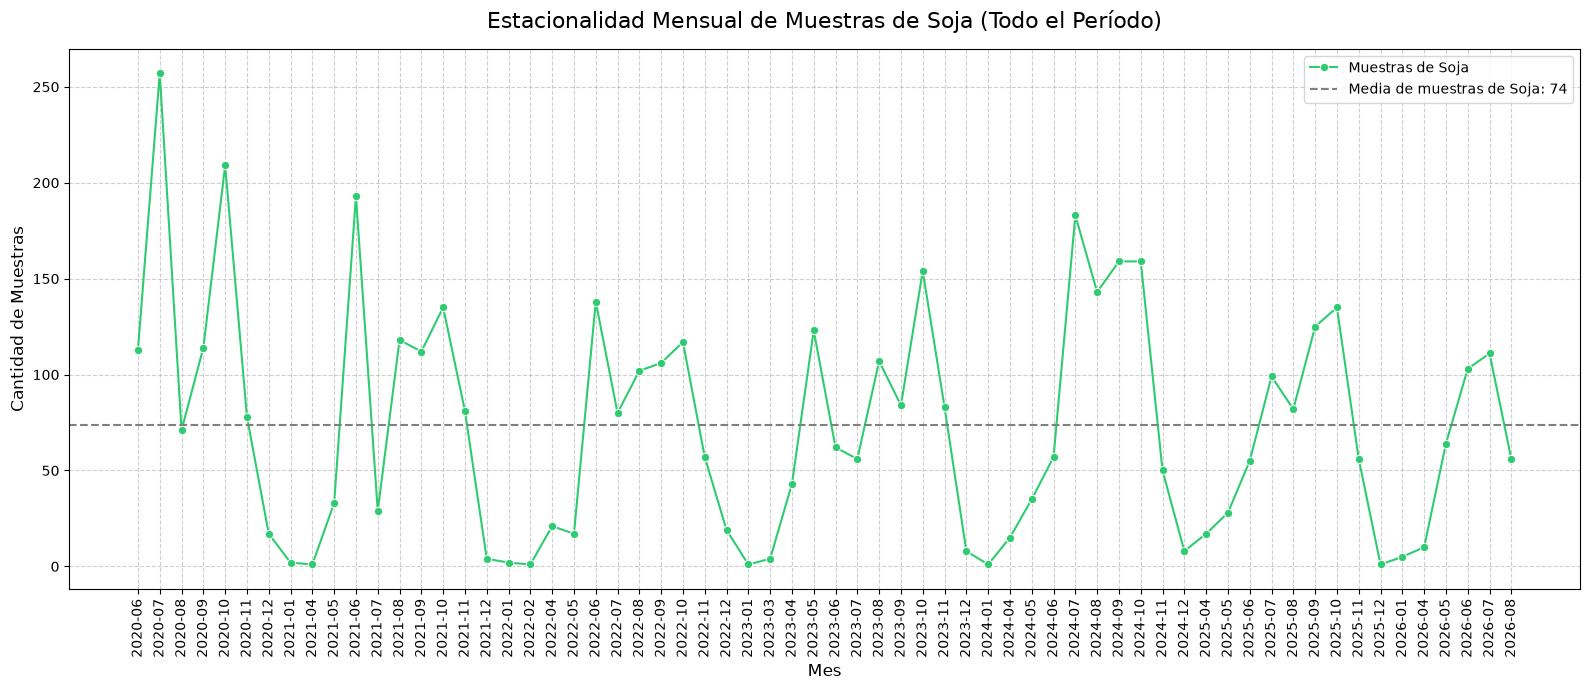

In [28]:
# Filtramos df_limpio para obtener solo las muestras de 'Soja'
df_soja = df_limpio[df_limpio['especies'].str.contains('Soja', case=False, na=False)].copy()

# Agrupamos por mes y contamos las muestras de Soja
# Aseguramos que la columna sea datetime para poder extraer el período
df_soja['fecha_ing_muestra'] = pd.to_datetime(df_soja['fecha_ing_muestra'])
muestras_soja_mensual = df_soja.groupby(df_soja['fecha_ing_muestra'].dt.to_period('M')).size().reset_index(name='cantidad_muestras')
muestras_soja_mensual['periodo_str'] = muestras_soja_mensual['fecha_ing_muestra'].astype(str)

# Calculamos la media de muestras de Soja por mes
media_soja_mensual = muestras_soja_mensual['cantidad_muestras'].mean()

# Creamos el gráfico de líneas
plt.figure(figsize=(16, 7))
sns.lineplot(
    x='periodo_str',
    y='cantidad_muestras',
    data=muestras_soja_mensual,
    marker='o',
    color='#2ecc71', # Un verde representativo para la soja
    label='Muestras de Soja'
)

# Agregamos la línea de la media
plt.axhline(
    y=media_soja_mensual,
    color='gray',
    linestyle='--',
    label=f'Media de muestras de Soja: {media_soja_mensual:.0f}'
)

# Etiquetas y título
plt.title('Estacionalidad Mensual de Muestras de Soja (Todo el Período)', fontsize=16, pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Muestras', fontsize=12)
plt.xticks(rotation=90) # Rotar las etiquetas del eje x para mejor legibilidad
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

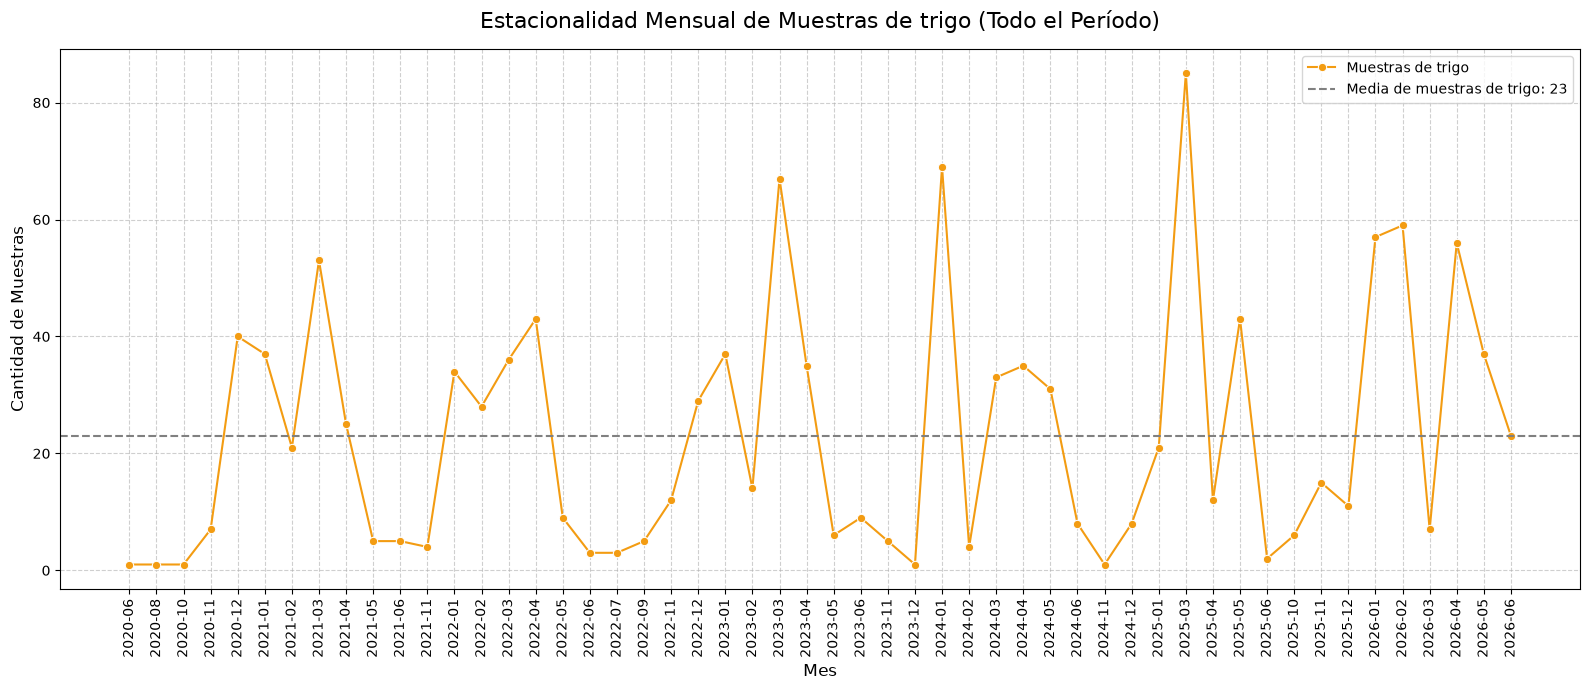

In [29]:
# Filtramos df_limpio para obtener solo las muestras de 'trigo'
df_trigo = df_limpio[df_limpio['especies'].str.contains('trigo', case=False, na=False)].copy()

# Agrupamos por mes y contamos las muestras de trigo
# Aseguramos que la columna sea datetime para poder extraer el período
df_trigo['fecha_ing_muestra'] = pd.to_datetime(df_trigo['fecha_ing_muestra'])
muestras_trigo_mensual = df_trigo.groupby(df_trigo['fecha_ing_muestra'].dt.to_period('M')).size().reset_index(name='cantidad_muestras')
muestras_trigo_mensual['periodo_str'] = muestras_trigo_mensual['fecha_ing_muestra'].astype(str)

# Calculamos la media de muestras de trigo por mes
media_trigo_mensual = muestras_trigo_mensual['cantidad_muestras'].mean()

# Creamos el gráfico de líneas
plt.figure(figsize=(16, 7))
sns.lineplot(
    x='periodo_str',
    y='cantidad_muestras',
    data=muestras_trigo_mensual,
    marker='o',
    color='#f39c12', # Un naranja representativo para trigo
    label='Muestras de trigo'
)

# Agregamos la línea de la media
plt.axhline(
    y=media_trigo_mensual,
    color='gray',
    linestyle='--',
    label=f'Media de muestras de trigo: {media_trigo_mensual:.0f}'
)

# Etiquetas y título
plt.title('Estacionalidad Mensual de Muestras de trigo (Todo el Período)', fontsize=16, pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Muestras', fontsize=12)
plt.xticks(rotation=90) # Rotar las etiquetas del eje x para mejor legibilidad
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

####OBJETIVO 4: Segmentar la Cartera: Clasificar a los clientes mediante técnica RFM (Recencia, Frecuencia, Valor Monetario) para diferenciar perfiles estratégicos de transaccionales

In [30]:
#Pareto de clientes (ajustado por inflacion, excluyendo codigos de convenio)

pareto_clientes = df_clientes.groupby('id_cliente')['importe_real'].sum()
pareto_clientes = pareto_clientes.sort_values(ascending=False)
pareto_acumulado = pareto_clientes.cumsum() / pareto_clientes.sum() * 100

top_20 = pareto_clientes.head(20)
porc_top20 = pareto_acumulado.iloc[19]
print(f"El Top 20 de clientes representa el {porc_top20:.1f}% de la facturacion total (ajustada por inflacion)")

El Top 20 de clientes representa el 73.0% de la facturacion total (ajustada por inflacion)


Pareto de Clientes — Concentración de Facturación (Top 20)

El análisis de Pareto aplicado a la cartera de clientes permite cuantificar el riesgo de dependencia comercial del laboratorio, respondiendo a la pregunta central del proyecto: ¿cuánto del negocio depende de muy pocos clientes?

Hallazgo principal: El Top 20 de clientes concentra la mayor parte de la facturación total del laboratorio. Esto confirma que el negocio opera bajo una distribución típica 80/20, donde una minoría de clientes sostiene la mayor parte de los ingresos.

Lectura estratégica por grupo:

Top 5 clientes (núcleo crítico): Son el corazón financiero del laboratorio. La pérdida de cualquiera de ellos tendría un impacto inmediato y significativo en los ingresos. Requieren atención comercial personalizada, seguimiento proactivo y condiciones preferenciales que justifiquen su permanencia.

Clientes del puesto 6 al 20 (zona de crecimiento): Representan el mayor potencial de expansión. Son clientes consolidados con margen para aumentar su volumen de envíos. Una estrategia de fidelización dirigida a este grupo puede mover la aguja de ingresos sin necesidad de captar nuevos clientes.

Resto de la cartera (larga cola): Clientes ocasionales o de bajo volumen que individualmente tienen poco impacto, pero colectivamente pueden representar un porcentaje relevante. Son candidatos naturales para campañas de activación masiva de bajo costo (email, WhatsApp).

Riesgo identificado: La alta concentración en pocos clientes expone al laboratorio a un riesgo estructural: si uno o dos clientes del Top 5 migran a un competidor o reducen su actividad por una mala campaña agrícola, el impacto en los ingresos puede ser difícil de compensar en el corto plazo.

Recomendación: Cruzar este análisis con el RFM para identificar cuáles de los clientes del Top 20 están en el segmento "En Riesgo" o "Potenciales". Esos casos son la prioridad comercial absoluta del laboratorio.

**Nota:** este porcentaje se calcula sobre `importe_real` (ajustado por inflacion, ver seccion 2.1) y excluyendo los codigos de convenio detectados en la seccion 2.2, para que la concentracion de facturacion no este distorsionada por el efecto de precios nominales entre 2020 y 2026.

In [31]:
# Se analiza la cartera de clientes 2025-2026
# Aseguramos formato datetime en la fecha de inicio
df_limpio['fecha_ing_muestra'] = pd.to_datetime(df_limpio['fecha_ing_muestra'], errors='coerce')

# FILTRADO: Tomamos todo el período 2025 y 2026 completo
df_ciclo = df_limpio[df_limpio['anio'].isin([2025, 2026])].copy()

# DEFINICIÓN DE REFERENCIA DINÁMICA: En lugar de fijar un día, tomamos el día de la última muestra registrada en el dataset
fecha_referencia = df_ciclo['fecha_ing_muestra'].max()
print(f"Fecha de referencia para el cálculo de Recencia: {fecha_referencia.strftime('%Y-%m-%d')}\n")

# Agrupamos por cliente para calcular R, F y M
rfm = df_ciclo.groupby('id_cliente').agg({
    'fecha_ing_muestra': lambda x: (fecha_referencia - x.max()).days, # Recencia (Días desde la última vez)
    'id_muestra': 'count',                                             # Frecuencia (Cantidad de órdenes)
    'importe_solicitud': 'sum'                                        # Valor Monetario (Facturación total)
})

# Renombramos columnas de origen
rfm.columns = ['recencia', 'frecuencia', 'valor_monetario']

# Creamos los Quintiles (Sectores del 1 al 5)
# Nota: En Recencia, menos días es mejor -> etiqueta 5 es el más reciente.
rfm['R'] = pd.qcut(rfm['recencia'], 5, labels=[5, 4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['frecuencia'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['valor_monetario'], 5, labels=[1, 2, 3, 4, 5])

# 6. Calculamos el Score RFM Final concatenando los quintiles
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

print("--- SEGMENTACIÓN RFM TOTAL (CAMPAÑA 2025-2026) ---")
print(rfm.sort_values('valor_monetario', ascending=False).head(10))

Fecha de referencia para el cálculo de Recencia: 2026-08-28

--- SEGMENTACIÓN RFM TOTAL (CAMPAÑA 2025-2026) ---
            recencia  frecuencia  valor_monetario  R  F  M RFM_Score
id_cliente                                                          
392               15         538     3.699190e+07  5  5  5       555
522               44         258     1.961290e+07  5  5  5       555
62                 9         195     1.370850e+07  5  5  5       555
104               30         171     1.117670e+07  5  5  5       555
2795             107          80     7.997000e+06  4  5  5       455
1328              10         119     6.838900e+06  5  5  5       555
714               64          58     4.809500e+06  5  5  5       555
9261              16          57     4.704400e+06  5  5  5       555
4281              32          61     4.595000e+06  5  5  5       555
350              368          63     3.956400e+06  1  5  5       155


Segmentación RFM — Campaña 2025-2026

El análisis RFM (Recencia, Frecuencia, Valor Monetario) permite clasificar a los clientes
según su comportamiento real de compra, yendo más allá del simple volumen de muestras.

1. Los Clientes Campeones (Scores: 555, 554, 545)
Quiénes son: Son los grandes semilleros o productores de la región. Mandan muestras de forma constante, sus últimos ingresos fueron hace muy pocos días y representan la mayor facturación del laboratorio.

 2. Los Clientes en Riesgo / Alerta Roja (Scores: 155, 154, 255)
Quiénes son: Este es el hallazgo más valioso del RFM. Son clientes que históricamente eran excelentes (Frecuencia 5, Monetario 5), pero su Recencia es muy baja (1 o 2), lo que significa que pasó la época de siembra o cosecha pesada y hace muchos meses que no mandan nada.

3. Clientes con Potencial de Desarrollo (Scores: 411, 422, 512)
Quiénes son: Clientes nuevos o chicos que enviaron sus primeras muestras hace muy poco (Recencia alta), pero su volumen (Frecuencia) y gasto acumulado aún son bajos.

 4. Clientes Dormidos / Hibernando (Scores: 222, 232, 322)
Quiénes son: Clientes medianos o de campañas muy específicas que muestran una actividad moderada pero espaciada en el tiempo.


### **4. Visualización**


Permite representar los datos de forma gráfica para facilitar su interpretación. A través de herramientas como histogramas, gráficos de barras, diagramas de caja (boxplots) o gráficos de dispersión, es posible identificar patrones, tendencias, agrupamientos y valores atípicos que no siempre son evidentes en tablas numéricas. Esta etapa es clave para comunicar hallazgos de manera clara y para apoyar la toma de decisiones basada en datos.

#####OBJETIVO 1: Analizar la demanda identificando clientes frecuentes por época del año y especie.
Adicional: Desarrollar un indicador de Alerta de Churn para clientes que no han enviado muestras en su periodo estacional habitual.

C:\Users\enzo_\AppData\Local\Temp\ipykernel_13968\115565135.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=clientes_reporte, x='segmento', palette={'Activo': '#2ecc71', 'En Riesgo': '#e74c3c'}, order=['Activo', 'En Riesgo'])


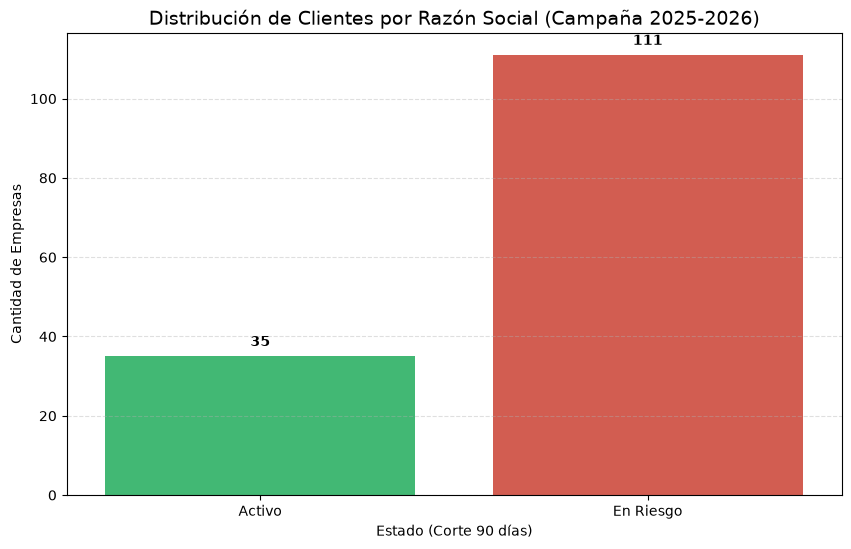

In [32]:
# Clientes segun días de inactividad
clientes_reporte['segmento'] = np.where(clientes_reporte['dias_inactivo'] > 90, 'En Riesgo', 'Activo')

plt.figure(figsize=(10, 6))
# Paleta profesional: Verde para activos, Rojo para riesgo
ax = sns.countplot(data=clientes_reporte, x='segmento', palette={'Activo': '#2ecc71', 'En Riesgo': '#e74c3c'}, order=['Activo', 'En Riesgo'])

# Añadimos las etiquetas de conteo sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.title('Distribución de Clientes por Razón Social (Campaña 2025-2026)', fontsize=14)
plt.ylabel('Cantidad de Empresas')
plt.xlabel('Estado (Corte 90 días)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Existen  35 clientes activos frente a 111 clientes en riesgo. Esto significa que casi el 75% de las empresas que alguna vez operaron en el ciclo 2025-2026 llevan más de 3 meses sin enviar muestras al laboratorio. De esos 111 clientes, muchos se encuentran bajo la "estacionalidad lógica" (productores de soja pura que solo aparecen en marzo/abril). Pero el peligro real radica en los clientes mixtos o cooperativas que deberían estar enviando muestras de trigo o análisis de suelo y no lo están haciendo.

Conclusión ejecutiva: "El análisis de actividad bajo el umbral de los 90 días expone una señal de alerta comercial crítica, con 111 cuentas catalogadas en situación de riesgo frente a 35 operativamente activas. Si bien este comportamiento se encuentra fuertemente influenciado por el bache biológico estacional de la temporada estival, la magnitud de la brecha exige una intervención proactiva. La organización no puede asumir un rol pasivo a la espera del inicio de la nueva campaña; se vuelve imperativo entrecruzar este padrón de alertas con la segmentación RFM previa para ejecutar un plan de contingencia comercial enfocado en el blindaje de las cuentas de alto valor histórico, aplicando incentivos financieros y reservas anticipadas de capacidad técnica para forzar la reactivación de las cuentas antes del pico operativo invernal."


Referencia de análisis: 2026-08-28
------------------------------
DISTRIBUCIÓN POR SEGMENTO:
segmento
Inactivo / Riesgo    325
Activo Regular        19
Fidelizado (VIP)      16
Name: count, dtype: int64
------------------------------

TOP 5 CLIENTES FIDELIZADOS:
     id_cliente  total_muestras  dias_inactivo
21          392            2204             15
10          104             452             30
9            62             284              9
64         1328             269             10
352        9261             186             16


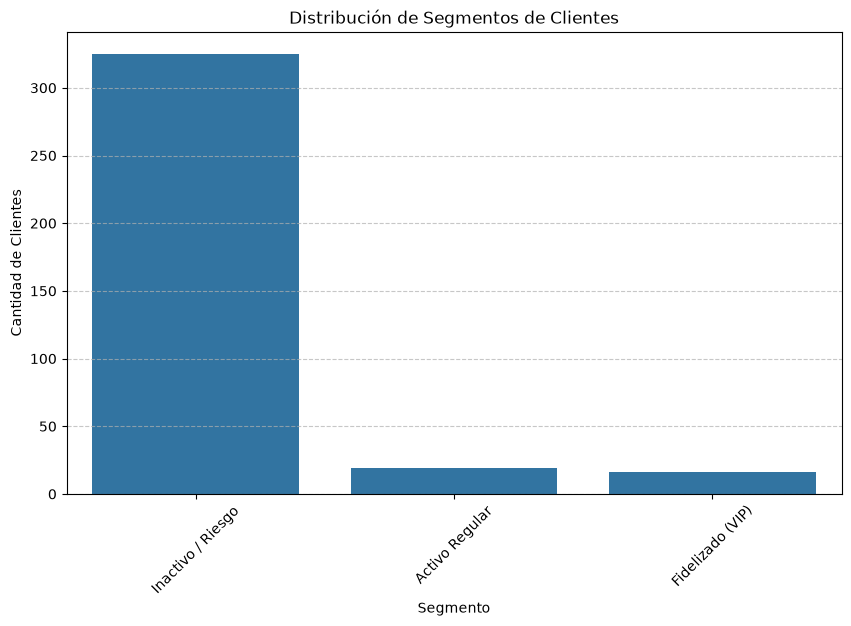

In [33]:
#Análisis de fidelización y riesgo

# 1. Definimos la fecha de referencia usando df_limpio
fecha_referencia = df_limpio['fecha_ing_muestra'].max()

# 2. Agrupamos por cliente utilizando df_limpio
segmentacion_clientes = df_limpio.groupby(['id_cliente']).agg(
    total_muestras=('id_muestra', 'count'),
    ultima_fecha=('fecha_ing_muestra', 'max'),
    primera_fecha=('fecha_ing_muestra', 'min')
).reset_index()

# 3. Calculamos la antigüedad y la inactividad en días
segmentacion_clientes['dias_inactivo'] = (fecha_referencia - segmentacion_clientes['ultima_fecha']).dt.days
segmentacion_clientes['antiguedad_dias'] = (fecha_referencia - segmentacion_clientes['primera_fecha']).dt.days

# 4. Aplicamos la lógica de segmentación profesional
def definir_segmento(row):
    if row['dias_inactivo'] > 90:
        return 'Inactivo / Riesgo'
    elif row['total_muestras'] == 1:
        return 'Nuevo / Ocasional'
    # Usamos la mediana calculada sobre los datos filtrados
    elif row['total_muestras'] > segmentacion_clientes['total_muestras'].median() and row['dias_inactivo'] <= 30:
        return 'Fidelizado (VIP)'
    else:
        return 'Activo Regular'

segmentacion_clientes['segmento'] = segmentacion_clientes.apply(definir_segmento, axis=1)

# 5. Resultados para el informe
print(f"Referencia de análisis: {fecha_referencia.date()}")
print("-" * 30)
print("DISTRIBUCIÓN POR SEGMENTO:")
print(segmentacion_clientes['segmento'].value_counts())
print("-" * 30)

# Ver los Top 5 Clientes Fidelizados
print("\nTOP 5 CLIENTES FIDELIZADOS:")
print(segmentacion_clientes[segmentacion_clientes['segmento'] == 'Fidelizado (VIP)']
      .sort_values('total_muestras', ascending=False)
      .head(5)[['id_cliente', 'total_muestras', 'dias_inactivo']])

# Generar el gráfico de barras para la distribución de segmentos
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=segmentacion_clientes, x='segmento', order=segmentacion_clientes['segmento'].value_counts().index)
plt.title('Distribución de Segmentos de Clientes')
plt.xlabel('Segmento')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

df_limpio['fecha_ing_muestra'] = pd.to_datetime(df_limpio['fecha_ing_muestra'])

El análisis de segmentación de clientes basado en la actividad reciente y la frecuencia de muestras revela patrones clave de comportamiento. Una parte significativa de los clientes se encuentra en la categoría 'Inactivo / Riesgo', lo que indica la necesidad de estrategias de retención. Los clientes 'Fidelizado (VIP)' son los más valiosos y requieren una atención especial para mantener su lealtad, mientras que los 'Activo Regular' representan una base sólida. Los clientes 'Nuevo / Ocasional' ofrecen una oportunidad para fomentar una mayor interacción y aumentar su valor a largo plazo


--- Análisis de los 20 Clientes Principales (2025-2026) ---


,id_cliente,total_muestras_enviadas,especie_dominante,conteo_especie_dominante,porcentaje_especie_dominante,tipo_cliente
4,392,538,Soja,403,74.907063,Estacional
5,522,258,Trigo,133,51.550388,Mixto
1,62,195,Maíz,49,25.128205,Mixto
2,104,171,Sorgo,68,39.766082,Mixto
11,1328,119,Gatton Panic,73,61.344538,Mixto
13,2795,80,Soja,80,100.000000,Estacional
17,4557,67,Trigo,26,38.805970,Mixto
3,350,63,Maíz,62,98.412698,Estacional
15,4281,61,Gatton Panic,37,60.655738,Mixto
7,714,58,Soja,29,50.000000,Mixto


C:\Users\enzo_\AppData\Local\Temp\ipykernel_13968\1048922134.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reporte_top20, x='tipo_cliente', palette='viridis')


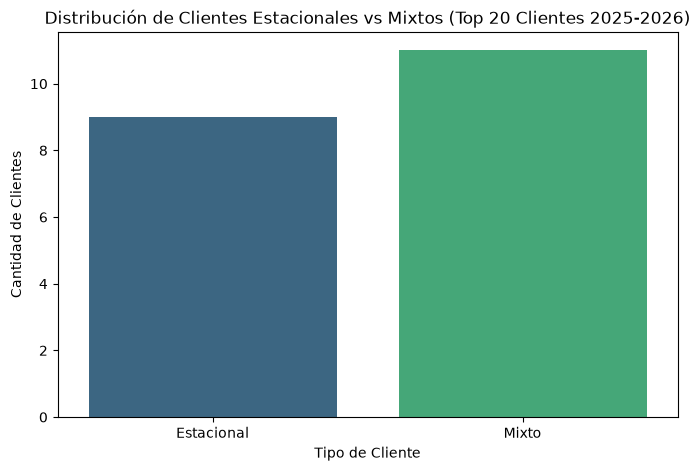

In [34]:
#1. Filtramos los datos para los últimos 2 años (2025 y 2026)
df_analisis = df_limpio[df_limpio['anio'].isin([2025, 2026])].copy()

# 2. Calculamos el total de muestras enviadas por cada cliente en este período
total_muestras_por_cliente = df_analisis.groupby('id_cliente')['id_muestra'].nunique().reset_index(name='total_muestras_enviadas')

# 3. Identificamos los 20 principales clientes por la cantidad de muestras enviadas
top_20_clientes_ids = total_muestras_por_cliente.sort_values(by='total_muestras_enviadas', ascending=False).head(20)['id_cliente'].tolist()

# 4. Filtramos el DataFrame para incluir solo a estos 20 principales clientes
df_top20 = df_analisis[df_analisis['id_cliente'].isin(top_20_clientes_ids)].copy()

# 5. Para cada uno de estos 20 clientes, determinamos su especie dominante y el conteo de muestras de esa especie
conteo_especies_top20 = df_top20.groupby(['id_cliente', 'especies']).size().reset_index(name='conteo_especie')

# Encontramos la especie con el conteo más alto para cada cliente
idx_max_especie = conteo_especies_top20.groupby('id_cliente')['conteo_especie'].idxmax()
especie_dominante_info = conteo_especies_top20.loc[idx_max_especie].rename(columns={'especies': 'especie_dominante', 'conteo_especie': 'conteo_especie_dominante'})

# 6. Combinamos la información y calculamos el porcentaje de la especie dominante
df_reporte_top20 = pd.merge(total_muestras_por_cliente, especie_dominante_info[['id_cliente', 'especie_dominante', 'conteo_especie_dominante']], on='id_cliente', how='inner')
df_reporte_top20['porcentaje_especie_dominante'] = (df_reporte_top20['conteo_especie_dominante'] / df_reporte_top20['total_muestras_enviadas']) * 100

# 7. Clasificamos a los clientes como "Estacional" o "Mixto"
df_reporte_top20['tipo_cliente'] = df_reporte_top20.apply(lambda row: 'Estacional' if row['porcentaje_especie_dominante'] > 70 else 'Mixto', axis=1)

# 8. Mostramos los resultados ordenados por el total de muestras enviadas
print("\n--- Análisis de los 20 Clientes Principales (2025-2026) ---")
display(df_reporte_top20.sort_values(by='total_muestras_enviadas', ascending=False))

# Graficamos la distribución de tipos de cliente
plt.figure(figsize=(8, 5))
sns.countplot(data=df_reporte_top20, x='tipo_cliente', palette='viridis')
plt.title('Distribución de Clientes Estacionales vs Mixtos (Top 20 Clientes 2025-2026)')
plt.xlabel('Tipo de Cliente')
plt.ylabel('Cantidad de Clientes')
plt.show()


Este análisis detallado de los 20 clientes con mayor volumen de muestras en 2025-2026 revela patrones de comportamiento cruciales. La visualización muestra la proporción de clientes 'Estacional' y 'Mixto'. Los clientes 'Estacional' son aquellos cuyas operaciones están fuertemente ligadas a una única especie dominante (más del 70% de sus muestras). Esta información es vital para la planificación de recursos, permitiendo anticipar los períodos de mayor demanda para especies específicas y personalizar la comunicación con los clientes según su tipo de actividad predominante. Una mayor proporción de clientes estacionales puede indicar una dependencia del laboratorio a ciclos de cultivo específicos, mientras que una mayor proporción de clientes mixtos podría sugerir una cartera más diversificada.

--- ANÁLISIS DE ACTIVIDAD DE CLIENTES (Referencia: 2026-08-28) ---
Total de clientes inactivos por más de 90 días: 111

--- CLASIFICACIÓN DE INACTIVIDAD AJUSTADA POR ESTACIONALIDAD ---


,id_cliente,ultima_muestra,dias_inactivo,especie_dominante,estado_riesgo_estacional
104,4947,2024-12-27,609,Buffel Grass,ALERTA: En Riesgo (No estacional principal o n...
21,960,2025-01-02,603,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)
12,441,2025-01-10,595,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)
64,3193,2025-01-15,590,Melilotus Albus,ALERTA: En Riesgo (No estacional principal o n...
65,3221,2025-03-07,539,Centeno,ALERTA: En Riesgo (No estacional principal o n...
39,1518,2025-03-19,527,Garbanzo,ALERTA: En Riesgo (No estacional principal o n...
121,6002,2025-03-20,526,Garbanzo,ALERTA: En Riesgo (No estacional principal o n...
91,4628,2025-03-21,525,Trigo Candeal,ALERTA: En Riesgo (No estacional principal o n...
62,2892,2025-04-24,491,Gatton Panic,ALERTA: En Riesgo (No estacional principal o n...
97,4738,2025-05-07,478,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)



--- RESUMEN DE ESTADOS DE RIESGO ESTACIONAL ---


C:\Users\enzo_\AppData\Local\Temp\ipykernel_13968\2176476313.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resumen_estados.index, y=resumen_estados.values, palette='viridis')


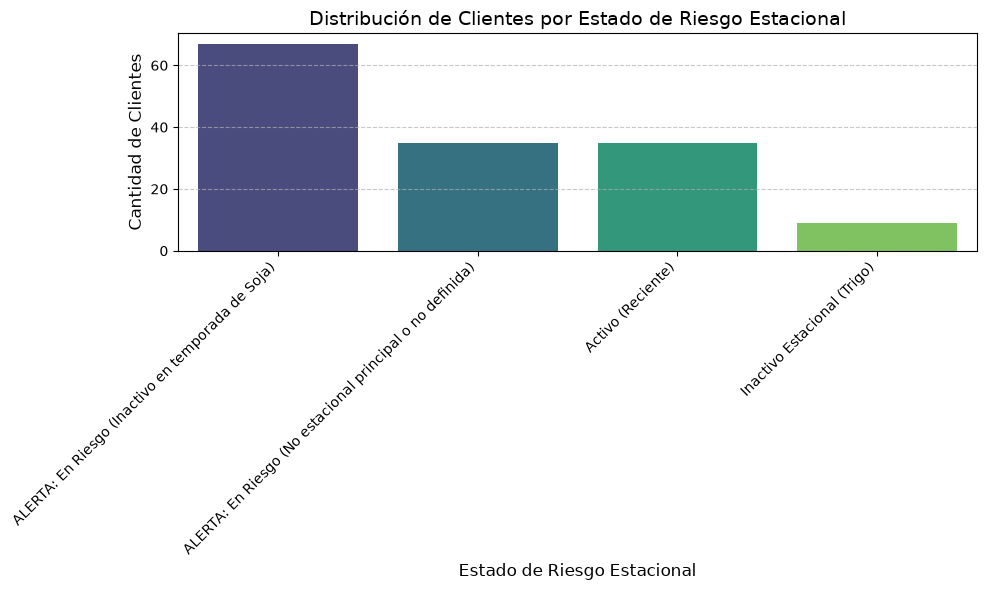


🚨 CLIENTES CON ALERTA REAL DE RIESGO (Inactivos en su temporada activa): 102


,id_cliente,ultima_muestra,dias_inactivo,especie_dominante,estado_riesgo_estacional
104,4947,2024-12-27,609,Buffel Grass,ALERTA: En Riesgo (No estacional principal o n...
21,960,2025-01-02,603,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)
12,441,2025-01-10,595,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)
64,3193,2025-01-15,590,Melilotus Albus,ALERTA: En Riesgo (No estacional principal o n...
65,3221,2025-03-07,539,Centeno,ALERTA: En Riesgo (No estacional principal o n...
39,1518,2025-03-19,527,Garbanzo,ALERTA: En Riesgo (No estacional principal o n...
121,6002,2025-03-20,526,Garbanzo,ALERTA: En Riesgo (No estacional principal o n...
91,4628,2025-03-21,525,Trigo Candeal,ALERTA: En Riesgo (No estacional principal o n...
62,2892,2025-04-24,491,Gatton Panic,ALERTA: En Riesgo (No estacional principal o n...
97,4738,2025-05-07,478,Soja,ALERTA: En Riesgo (Inactivo en temporada de Soja)


In [35]:
# Demanda por cliente considerando la estacionalidad del cultivo principal.

# Filtramos del año 2025 en adelante
df_reciente = df_limpio[df_limpio['anio'] >= 2025].copy()

# Referencia temporal
hoy_reciente = df_reciente['fecha_ing_muestra'].max()

# Agrupamos por id_cliente para el listado técnico de actividad reciente
clientes_reporte = df_reciente.groupby('id_cliente').agg(
    ultima_muestra=('fecha_ing_muestra', 'max'),
    total_pedidos=('id_muestra', 'nunique')
).reset_index()

# Cálculo de inactividad
clientes_reporte['dias_inactivo'] = (hoy_reciente - clientes_reporte['ultima_muestra']).dt.days

# --- INICIO DE LA MODIFICACIÓN PARA INCORPORAR CULTIVO PRINCIPAL Y ESTACIONALIDAD ---

# 1. Determinar la especie dominante para CADA cliente en todo el historial
# Agrupamos por cliente y especie, contamos muestras
conteo_especies_todos_clientes = df_limpio.groupby(['id_cliente', 'especies']).size().reset_index(name='conteo_especie')

# Encontramos la especie con el conteo más alto para cada cliente
idx_max_especie_general = conteo_especies_todos_clientes.groupby('id_cliente')['conteo_especie'].idxmax()
especie_dominante_info_general = conteo_especies_todos_clientes.loc[idx_max_especie_general].rename(columns={'especies': 'especie_dominante', 'conteo_especie': 'conteo_especie_dominante'})

# Unir esta información al reporte de clientes
clientes_reporte = pd.merge(clientes_reporte, especie_dominante_info_general[['id_cliente', 'especie_dominante']], on='id_cliente', how='left')

# 2. Definir meses activos para las especies principales
# Basado en el análisis de estacionalidad (celda ImNCJkCHWbmb):
# Soja: pico entre julio y octubre (meses 7, 8, 9, 10)
# Trigo: pico entre enero y mayo (meses 1, 2, 3, 4, 5)
active_months_soja = [7, 8, 9, 10]
active_months_trigo = [1, 2, 3, 4, 5]

# 3. Función para determinar el estado de riesgo ajustado por estacionalidad
def get_seasonal_risk_status(row, current_reference_date):
    dias_inactivo = row['dias_inactivo']
    dominant_species = row['especie_dominante']
    current_month = current_reference_date.month

    if dias_inactivo <= 90:
        return 'Activo (Reciente)' # No inactivo el tiempo suficiente para considerar riesgo

    # Si está inactivo más de 90 días, aplicamos la lógica estacional
    if pd.isna(dominant_species): # Handle cases where dominant species could not be determined
        return 'ALERTA: En Riesgo (No estacional principal o no definida)'
    elif dominant_species.lower() == 'soja':
        if current_month in active_months_soja:
            # Es temporada de Soja, pero el cliente está inactivo > 90 días
            return 'ALERTA: En Riesgo (Inactivo en temporada de Soja)'
        else:
            # Es temporada baja para Soja, inactividad podría ser estacional
            return 'Inactivo Estacional (Soja)'
    elif dominant_species.lower() == 'trigo':
        if current_month in active_months_trigo:
            # Es temporada de Trigo, pero el cliente está inactivo > 90 días
            return 'ALERTA: En Riesgo (Inactivo en temporada de Trigo)'
        else:
            # Es temporada baja para Trigo, inactividad podría ser estacional
            return 'Inactivo Estacional (Trigo)'
    else:
        # Para otras especies no clasificadas como estacionales principales, se considera riesgo general
        return 'ALERTA: En Riesgo (No estacional principal o no definida)'

# Aplicar la función para categorizar el riesgo
clientes_reporte['estado_riesgo_estacional'] = clientes_reporte.apply(
    lambda row: get_seasonal_risk_status(row, hoy_reciente), axis=1
)

# --- FIN DE LA MODIFICACIÓN ---

print(f"--- ANÁLISIS DE ACTIVIDAD DE CLIENTES (Referencia: {hoy_reciente.date()}) ---")

# Filtrar solo los que cumplen la condición de más de 90 días de inactividad
listado_inactivos_general = clientes_reporte[clientes_reporte['dias_inactivo'] > 90].sort_values('dias_inactivo', ascending=False)

print(f"Total de clientes inactivos por más de 90 días: {len(listado_inactivos_general)}\n")

print("--- CLASIFICACIÓN DE INACTIVIDAD AJUSTADA POR ESTACIONALIDAD ---")
display(listado_inactivos_general[['id_cliente', 'ultima_muestra', 'dias_inactivo', 'especie_dominante', 'estado_riesgo_estacional']].head(15))

# Resumen de estados de riesgo
resumen_estados = clientes_reporte['estado_riesgo_estacional'].value_counts()
print("\n--- RESUMEN DE ESTADOS DE RIESGO ESTACIONAL ---")

# Visualización de los estados de riesgo
plt.figure(figsize=(10, 6))
sns.barplot(x=resumen_estados.index, y=resumen_estados.values, palette='viridis')
plt.title('Distribución de Clientes por Estado de Riesgo Estacional', fontsize=14)
plt.xlabel('Estado de Riesgo Estacional', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Opcional: Para el listado de 'ALERTA: En Riesgo' que requiere acción comercial
clientes_en_alerta = listado_inactivos_general[listado_inactivos_general['estado_riesgo_estacional'].str.startswith('ALERTA')].copy()
print(f"\n🚨 CLIENTES CON ALERTA REAL DE RIESGO (Inactivos en su temporada activa): {len(clientes_en_alerta)}")
if not clientes_en_alerta.empty:
    display(clientes_en_alerta[['id_cliente', 'ultima_muestra', 'dias_inactivo', 'especie_dominante', 'estado_riesgo_estacional']].head(10))

##### OBJETIVO 2: Identificar los intervalos críticos de demanda por cultivo para optimizar la asignación de personal e insumos.

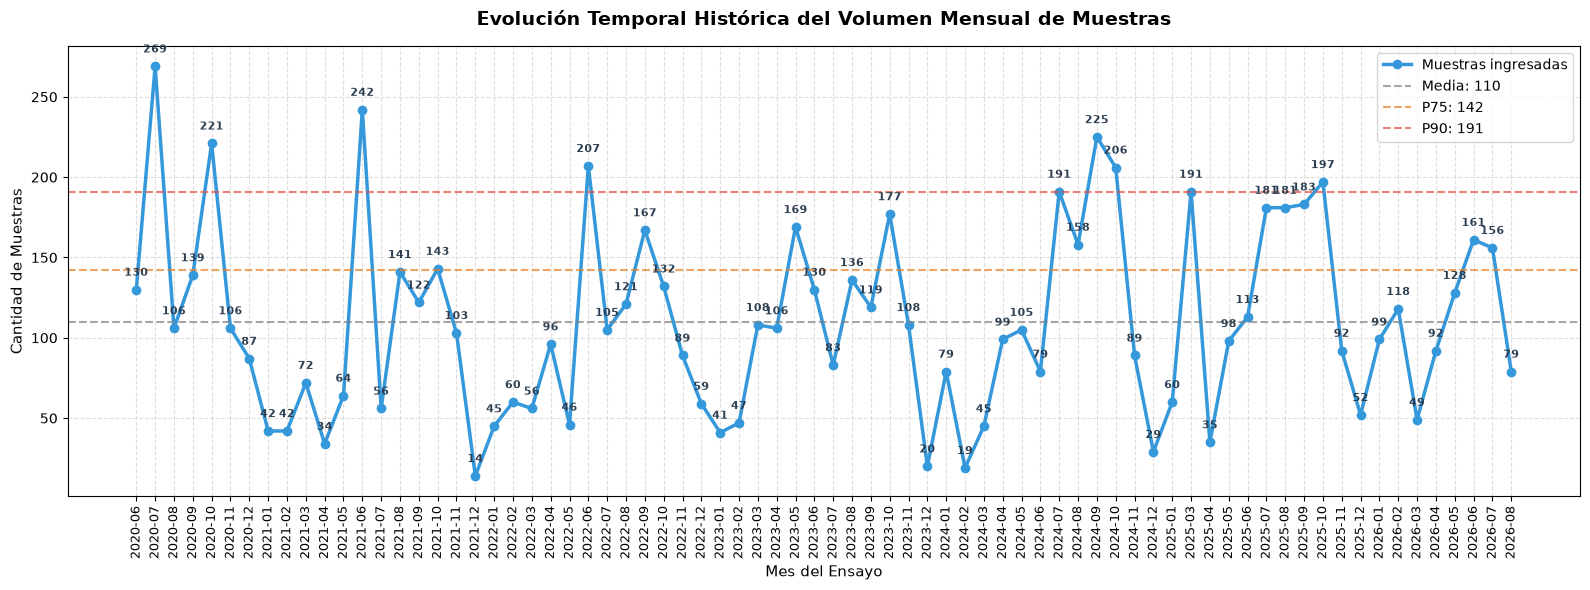

Nota operativa: planificar capacidad en base al P75 (142) o P90 (191), no en la media (110).


In [36]:
# ── GRAFICO DE DEMANDA DE VOLUMEN MENSUAL ───────────────
df_limpio['periodo'] = df_limpio['fecha_ing_muestra'].dt.to_period('M')
vol_mensual = df_limpio.groupby('periodo').size().reset_index(name='muestras')
vol_mensual['periodo_str'] = vol_mensual['periodo'].astype(str)

# Percentiles para referencia operativa
p75 = vol_mensual['muestras'].quantile(0.75)
p90 = vol_mensual['muestras'].quantile(0.90)

fig, ax = plt.subplots(figsize=(16, 6))

# CAMBIO CLAVE: De barras a línea continua con marcadores ('-o')
ax.plot(vol_mensual['periodo_str'], vol_mensual['muestras'], color='#3498db', linewidth=2.5, marker='o', label='Muestras ingresadas')

# Mantenemos las líneas de referencia operativa
ax.axhline(y=vol_mensual['muestras'].mean(), color='gray', linestyle='--', alpha=0.7, label=f"Media: {vol_mensual['muestras'].mean():.0f}")
ax.axhline(y=p75, color='#e67e22', linestyle='--', alpha=0.7, label=f"P75: {p75:.0f}")
ax.axhline(y=p90, color='#e74c3c', linestyle='--', alpha=0.7, label=f"P90: {p90:.0f}")

# Agregamos las etiquetas numéricas sobre cada punto para no perder precisión
for i, txt in enumerate(vol_mensual['muestras']):
    ax.annotate(int(txt), (vol_mensual['periodo_str'].iloc[i], vol_mensual['muestras'].iloc[i]),
                textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', fontsize=8, color='#2c3e50')

# Estética general
ax.set_title('Evolución Temporal Histórica del Volumen Mensual de Muestras', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes del Ensayo', fontsize=11)
ax.set_ylabel('Cantidad de Muestras', fontsize=11)
plt.xticks(rotation=90, fontsize=9)
ax.legend(loc='upper right')
ax.grid(axis='both', linestyle='--', alpha=0.4) # Cuadrícula en ambos ejes ayuda a seguir la línea

plt.tight_layout()
plt.show()

print(f"Nota operativa: planificar capacidad en base al P75 ({p75:.0f}) o P90 ({p90:.0f}), no en la media ({vol_mensual['muestras'].mean():.0f}).")

1. Diagnóstico Estructural: El "Pulso" del Laboratorio
Patrón de Ondas Estacionales: El gráfico lineal revela que la demanda del laboratorio no es lineal ni aleatoria, sino altamente cíclica. Visualmente se comporta mostrando valles profundos y crestas agudas que se repiten como tendencia en cada campaña agrícola.
El Impacto de la Cosecha (Picos): Los picos más prominentes representan los meses donde ingresan de manera masiva los ensayos de cultivos de cosecha gruesa y fina (como soja y trigo). En estos puntos, la curva se dispara exponencialmente hacia arriba, reflejando el momento exacto en que los productores y cooperativas necesitan validar la calidad de sus semillas antes de la comercialización o la siembra.
2. Líneas de Referencia (Gestión de Capacidad)
La inclusión de la media, el Percentil 75 (P75) y el Percentil 90 (P90) transforma esta visualización de un simple reporte histórico a una herramienta estratégica de simulación operativa:
El peligro de planificar con la Media: La línea de la media aritmética es engañosa para este modelo de negocio. Si el laboratorio dimensionara su personal, reactivos y capacidad de planta basándose en el promedio, quedaría completamente colapsado durante casi la mitad de cada año.
El P75 como Umbral de Alerta Operativa: Cuando la curva supera la línea del P75, el laboratorio 8ingresa en su zona de alta demanda. Este nivel indica que el volumen es superior al 75% de los meses históricos, marcando el momento en que se deben activar de forma preventiva las horas extras y evaluación de contratación de personal adicional.
El P90 como Zona de Cuellos de Botella (SLA en Riesgo- TIEMPOS DE ENTRAGA DE RESULTADOS): Los picos que tocan o superan la línea roja del P90 representan escenarios de estrés extremo. En estos meses específicos, la infraestructura trabaja a su máxima capacidad instalada. Es el indicador clave que justifica técnicamente la contratación de personal temporal y la compra anticipada de insumos.

Persistencia de la Pendiente: Un hallazgo crítico al mirar las etiquetas numéricas (ax.annotate) es la velocidad con la que el laboratorio pasa de un mes de calma a un mes de saturación. La pendiente empinada de la línea al subir demuestra que el laboratorio no tiene una transición suave; la demanda entra de golpe, lo que exige una flexibilidad operativa inmediata.


--- EVOLUCIÓN HISTÓRICA DE LAS 5 PRINCIPALES ESPECIES ---
especies  Gatton Panic  Maíz  Soja  Sorgo  Trigo
anio                                            
2020                 8    58   859     18     23
2021                12    39   708     24    170
2022                41    34   659     31    159
2023                92    49   724     45    196
2024                56    36   812     39    189
2025                94   131   598     67    183
2026                64    27   349     22    239


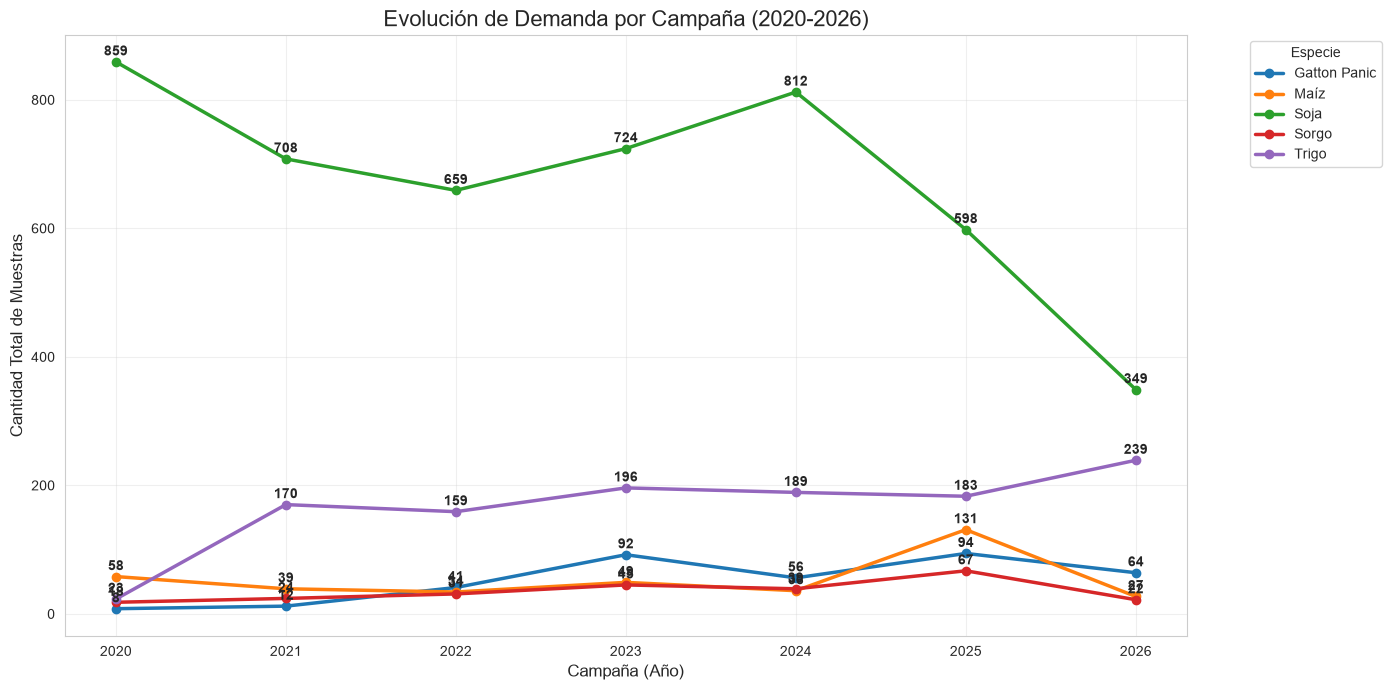

In [37]:
# Identificamos las 5 especies con más muestras en TODA la historia del dataset
top_5_global = df_limpio['especies'].value_counts().head(5).index.tolist()

# Filtramos el DataFrame solo para esas 5 especies
df_top5_historico = df_limpio[df_limpio['especies'].isin(top_5_global)].copy()

# Agrupamos por Año y Especie para contar el volumen
# Usamos el año que ya tenemos calculado en la columna 'ano'
evolucion_historica = df_top5_historico.groupby(['anio', 'especies']).size().unstack(fill_value=0)

print("--- EVOLUCIÓN HISTÓRICA DE LAS 5 PRINCIPALES ESPECIES ---")
print(evolucion_historica)

# CREACIÓN DEL GRÁFICO
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Graficamos cada especie con una línea y marcadores
for especie in evolucion_historica.columns:
    plt.plot(evolucion_historica.index.astype(str), evolucion_historica[especie],
             marker='o', linewidth=2.5, label=especie)

    # Añadimos etiquetas de valor en cada punto para mayor claridad
    for x, y in zip(evolucion_historica.index.astype(str), evolucion_historica[especie]):
        plt.text(x, y + 10, str(int(y)), ha='center', fontweight='bold', fontsize=10)

plt.title('Evolución de Demanda por Campaña (2020-2026)', fontsize=16)
plt.xlabel('Campaña (Año)', fontsize=12)
plt.ylabel('Cantidad Total de Muestras', fontsize=12)
plt.legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Evolución de demanda por campaña (2020–2026)

Este gráfico multi-línea expone la **jerarquía histórica** de la cartera de servicios del laboratorio y la evolución de cada especie año a año.

**Lectura estructural:** Soja aparece consistentemente como la línea dominante en todos los años con datos disponibles, ratificando su condición de especie motor del negocio. Trigo ocupa el segundo lugar con una participación estable.

**Riesgo de concentración:** La brecha visual entre la línea de soja y el resto de las especies cuantifica el riesgo de dependencia. Una mala campaña agrícola de soja en Córdoba (por sequía, exceso hídrico o problemas sanitarios) impacta directamente en los ingresos del laboratorio de forma casi proporcional, ya que ninguna otra especie puede compensar ese volumen en el corto plazo.

**Conclusión estratégica:** La evolución histórica confirma que el laboratorio no ha logrado diversificar su matriz productiva a lo largo de los años. Este es un hallazgo de largo plazo que debería motivar al área comercial a explorar activamente análisis de especies con menor estacionalidad o mayor distribución temporal.

#### OBJETIVO 3: Conocer la estacionalidad de las especies dominantes de la demanda


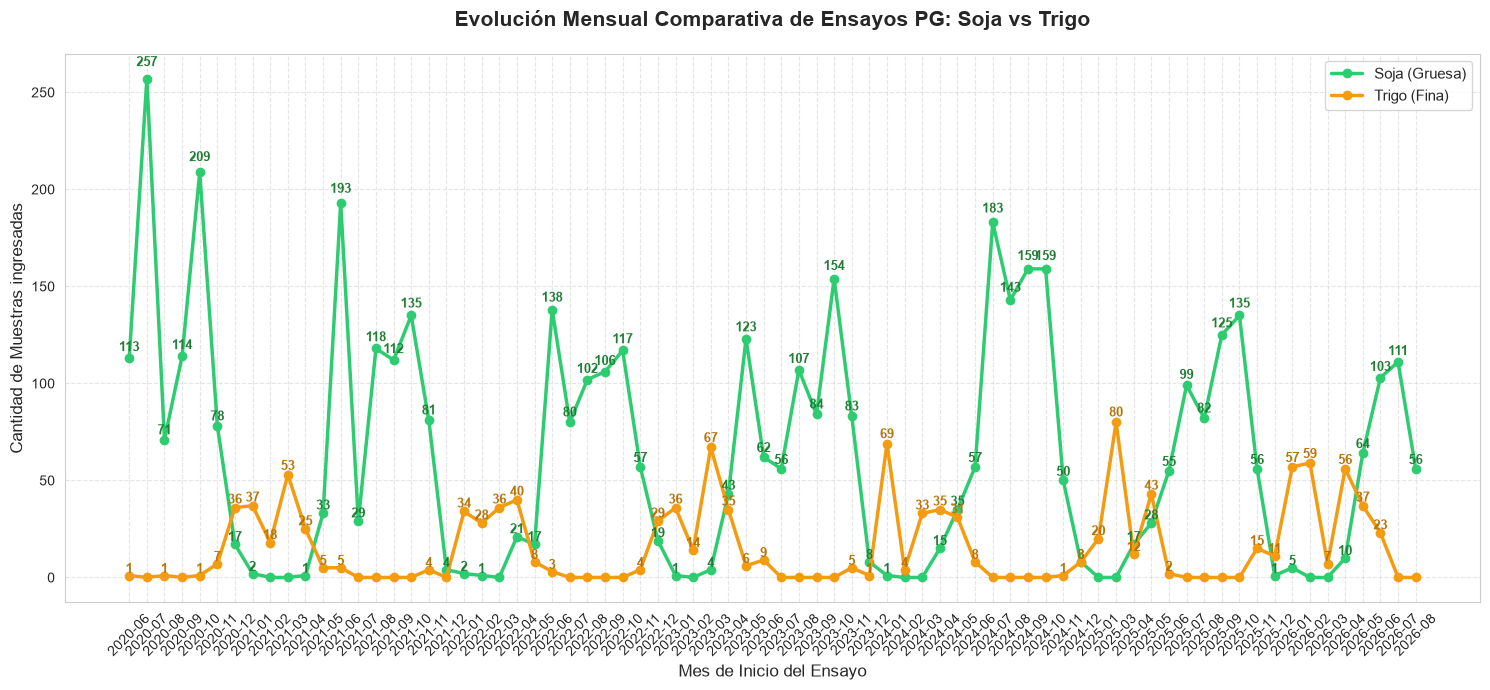

In [38]:
# 1. Aseguramos formato datetime
df_limpio['fecha_ing_muestra'] = pd.to_datetime(df_limpio['fecha_ing_muestra'], errors='coerce')

# 2. Definimos límites del ciclo
fecha_inicio = pd.to_datetime('2020-06-01')
fecha_fin = pd.to_datetime('2026-08-28')

# 3. FILTRADO: Traemos Soja y Trigo en simultáneo
df_ambos = df_limpio[
    (df_limpio['especies'].str.lower().str.strip().isin(['soja', 'trigo'])) &
    (df_limpio['fecha_ing_muestra'] >= fecha_inicio) &
    (df_limpio['fecha_ing_muestra'] <= fecha_fin)
].copy()

# 4. Agrupamos por mes y por especie, y pivotamos con unstack
df_agrupado = df_ambos.groupby(
    [df_ambos['fecha_ing_muestra'].dt.to_period('M'), 'especies']
).size().unstack(fill_value=0)

# Aseguramos que el índice sea texto ordenado para el eje X
df_agrupado.index = df_agrupado.index.astype(str)

# ============================================================
# GRÁFICO COMPARATIVO DE LÍNEAS CONTINUAS (SOJA VS TRIGO)
# ============================================================
if df_agrupado.empty:
    print("El DataFrame agrupado está vacío. Revisá las etiquetas de tus especies o ensayos.")
else:
    plt.figure(figsize=(15, 7))

    # Guardamos los meses para el eje X
    meses = df_agrupado.index

    # LÍNEA DE SOJA (Verde)
    if 'Soja' in df_agrupado.columns:
        plt.plot(meses, df_agrupado['Soja'], color='#2ecc71', linewidth=2.5, marker='o', label='Soja (Gruesa)')

        # Etiquetas numéricas para Soja
        for i, val in enumerate(df_agrupado['Soja']):
            if val > 0:
                plt.text(i, val + (val * 0.02), int(val), va='bottom', ha='center',
                         fontweight='bold', fontsize=9, color='#1e7e34')

    # LÍNEA DE TRIGO (Dorada)
    if 'Trigo' in df_agrupado.columns:
        plt.plot(meses, df_agrupado['Trigo'], color='#f39c12', linewidth=2.5, marker='o', label='Trigo (Fina)')

        # Etiquetas numéricas para Trigo
        for i, val in enumerate(df_agrupado['Trigo']):
            if val > 0:
                plt.text(i, val + (val * 0.02), int(val), va='bottom', ha='center',
                         fontweight='bold', fontsize=9, color='#b77305')

    # Ajustes estéticos y títulos
    plt.title('Evolución Mensual Comparativa de Ensayos PG: Soja vs Trigo', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Mes de Inicio del Ensayo', fontsize=12)
    plt.ylabel('Cantidad de Muestras ingresadas', fontsize=12)

    plt.xticks(rotation=45)
    plt.legend(fontsize=11, loc='upper right')

    # Cuadrícula en ambos ejes para cruzar mejor los puntos de las líneas
    plt.grid(axis='both', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

Evolución Mensual Comparativa de Ensayos PG — Soja vs Trigo

Patrón estacional dominante

El volumen de trabajo del laboratorio sigue un patrón estacional muy marcado, dominado por dos campañas agrícolas con comportamientos **cíclicos inversos**:

| Indicador | Valor / Estado |
|-----------|---------------|
| Campaña Gruesa (Soja) | Mayor intensidad — Pico entre julio y octubre |
| Campaña Fina (Trigo) | Menor intensidad — Pico entre enero y mayo |


Soja — Campaña Gruesa
La demanda de soja presenta un pico explosivo concentrado entre **julio y octubre**, alcanzando su máximo absoluto en **septiembre/octubre**. Luego cae pronunciadamente hacia fin de año.

Trigo — Campaña Fina
El trigo muestra un comportamiento exactamente inverso: su actividad se activa con fuerza a partir de **diciembre**, alcanzando un pico entre **abril y mayo**. Los valores caen a partir de junio, momento en que ya se ha sembrado la fina.

⚠️ Valle productivo crítico: noviembre – enero

Al observar la interacción de ambas líneas, se detecta un **trimestre de capacidad ociosa** donde el volumen de ambas especies cae a su punto más bajo.

> **Hallazgo clave de Inteligencia de Negocio:** Este es el período ideal para concentrar labores no habituales, mantenimientos pesados de cámaras de germinación, licencias y vacaciones del personal de planta. El laboratorio **no debe dimensionar su estructura técnica de forma fija**.

💡 Hallazgo estratégico: demanda concentrada y predecible

La estacionalidad es un **activo estratégico**: el laboratorio puede planificar con antelación su dotación de personal, stock de insumos y capacidad de respuesta. No hay excusas para ser tomados por sorpresa en los picos de campaña.

📈 Oportunidad comercial contra-estacional

Dado que soja y trigo desaparecen en los meses de verano, el equipo comercial debería impulsar **servicios alternativos de baja estacionalidad** o análisis de cultivos regionales que operen en fechas distintas, logrando un flujo de ingresos más estable hacia fin de año.

Conclusión ejecutiva

> *"La evolución mensual comparativa entre Soja y Trigo ratifica la naturaleza cíclica inversa de la demanda técnica del laboratorio. Esta alternancia biológica genera un **valle crítico de facturación y actividad entre noviembre y enero**, hito que debe ser capitalizado por la organización para programar paradas técnicas, vacaciones del personal y desplegar campañas comerciales contra-estacionales."*



####OBJETIVO 4: Segmentar la Cartera: Clasificar a los clientes mediante técnica RFM (Recencia, Frecuencia, Valor Monetario) para diferenciar perfiles estratégicos de transaccionales.

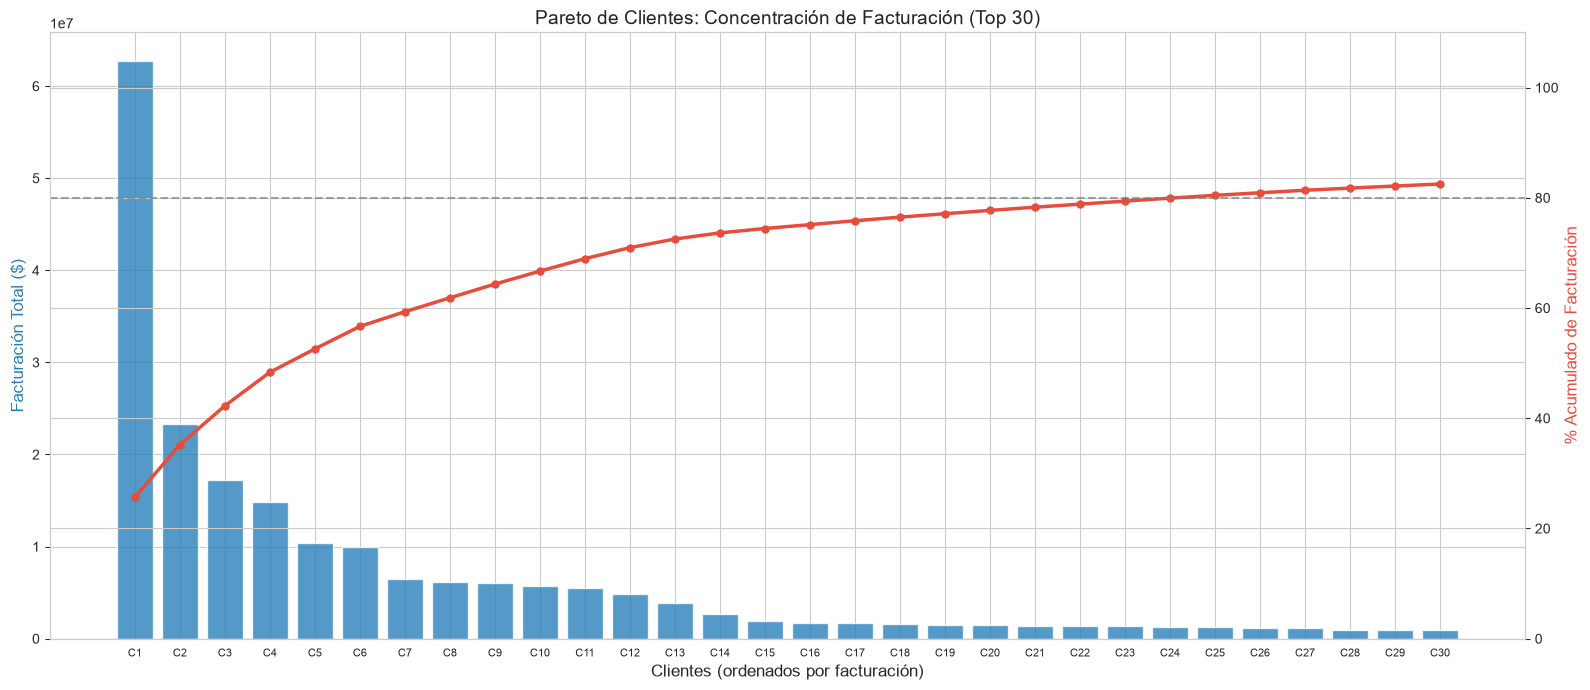

El 80% de la facturación está concentrada en 25 clientes
Sobre un total de 1 clientes activos


In [39]:
# Pareto de Clientes - Concentración de Facturación
pareto_clientes = (df_limpio.groupby('id_cliente')['importe_solicitud']
                   .sum()
                   .sort_values(ascending=False))

# Calculamos el acumulado porcentual
acumulado = pareto_clientes.cumsum() / pareto_clientes.sum() * 100

# Tomamos el Top 30 para que el gráfico sea legible
top_n = 30
pareto_top = pareto_clientes.head(top_n)
acumulado_top = acumulado.head(top_n)

fig, ax1 = plt.subplots(figsize=(16, 7))

# Barras de facturación
ax1.bar(range(top_n), pareto_top.values, color='#2980b9', alpha=0.8, label='Facturación')
ax1.set_xlabel('Clientes (ordenados por facturación)', fontsize=12)
ax1.set_ylabel('Facturación Total ($)', fontsize=12, color='#2980b9')
ax1.set_xticks(range(top_n))
ax1.set_xticklabels([f'C{i+1}' for i in range(top_n)], fontsize=8)

# Línea acumulada
ax2 = ax1.twinx()
ax2.plot(range(top_n), acumulado_top.values, color='#e74c3c',
         marker='o', linewidth=2.5, markersize=5, label='% Acumulado')
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='Umbral 80%')
ax2.set_ylabel('% Acumulado de Facturación', fontsize=12, color='#e74c3c')
ax2.set_ylim(0, 110)

plt.title('Pareto de Clientes: Concentración de Facturación (Top 30)', fontsize=14)
fig.tight_layout()
plt.show()

# Calculamos cuántos clientes llegan al 80%
clientes_80 = (acumulado <= 80).sum() + 1
print(f"El 80% de la facturación está concentrada en {clientes_80} clientes")
print(f"Sobre un total de {df_limpio['razon_social'].nunique()} clientes activos")

Pareto de clientes — Concentración de facturación (Top 30)

El gráfico de Pareto combina dos dimensiones en un único visual: el **volumen de facturación individual** de cada cliente (barras azules) y la **curva de concentración acumulada** (línea roja).

**Lectura del punto de quiebre:** El cruce entre la línea roja y la línea gris punteada del 80% indica cuántos clientes concentran el 80% de los ingresos totales del laboratorio. Cuanto más a la izquierda ocurre ese cruce, mayor es el riesgo de dependencia estructural.

**Gradiente de barras:** La caída pronunciada entre las primeras barras (clientes C1–C6) y el resto de la serie revela que no existe una distribución gradual de la facturación, sino un escalón abrupto. Esto significa que la diferencia entre el cliente número 1 y el número 10 en ingresos es sustancial, lo que amplifica el riesgo asociado a la pérdida de cualquiera de los primeros puestos.

**Zona de alerta comercial (C1–C6):** Estos clientes son el núcleo financiero del laboratorio. Una desvinculación en este grupo —ya sea por mala campaña, captación por competencia o conflicto de servicio— generaría un impacto que ningún otro cliente podría compensar en el corto plazo. Son candidatos naturales para el protocolo de Alerta Roja del sistema de Churn.

**Zona de crecimiento (C7–C20):** Son clientes consolidados con margen para aumentar su volumen de envíos. Una estrategia de fidelización enfocada en este grupo puede mover la aguja de ingresos sin necesidad de captar clientes nuevos.

**Recomendación:** Cruzar este ranking con los resultados del análisis RFM para identificar cuáles de estos clientes tienen un score de recencia bajo. Esos casos son la prioridad comercial absoluta: alta facturación histórica combinada con señales de inactividad reciente.

Fecha de referencia para el cálculo de Recencia: 2026-08-28



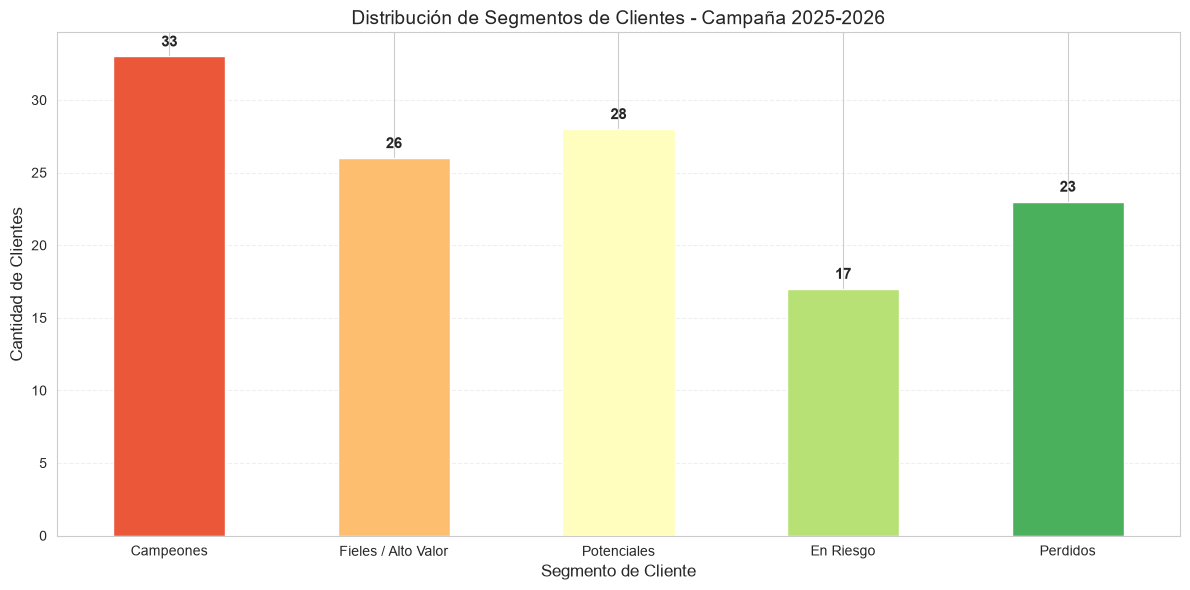

In [40]:
# 1. Definimos una lógica de segmentación basada en el Score RFM
def segmentar_rfm(df):
    # Score total sumando R, F y M (va de 3 a 15)
    total_score = int(df['R']) + int(df['F']) + int(df['M'])

    if total_score >= 13:
        return 'Campeones'
    elif total_score >= 10:
        return 'Fieles / Alto Valor'
    elif total_score >= 7:
        return 'Potenciales'
    elif total_score >= 5:
        return 'En Riesgo'
    else:
        return 'Perdidos'

# Re-calculate RFM data from previous steps
# Aseguramos formato datetime en la fecha de inicio
df_limpio['fecha_ing_muestra'] = pd.to_datetime(df_limpio['fecha_ing_muestra'], errors='coerce')

# FILTRADO: Tomamos el período solicitado por el usuario
start_date = pd.to_datetime('2025-08-28')
end_date = pd.to_datetime('2026-08-28')
df_2526 = df_limpio[(df_limpio['fecha_ing_muestra'] >= start_date) & (df_limpio['fecha_ing_muestra'] <= end_date)].copy()

# Definimos la fecha de referencia dinámicamente
fecha_referencia = df_2526['fecha_ing_muestra'].max()
print(f"Fecha de referencia para el cálculo de Recencia: {fecha_referencia.strftime('%Y-%m-%d')}\n")


# Agrupamos por cliente para calcular R, F y M
rfm = df_2526.groupby('id_cliente').agg({
    'fecha_ing_muestra': lambda x: (fecha_referencia - x.max()).days, # Recencia
    'id_muestra': 'count',                                             # Frecuencia
    'importe_solicitud': 'sum'                                        # Valor Monetario (using corrected column name)
})

# Renombramos columnas
rfm.columns = ['recencia', 'frecuencia', 'valor_monetario']

# Creamos los Quintiles (Sectores del 1 al 5)
# Nota: En Recencia, el menor número es mejor (1), en F y M el mayor es mejor (5)
rfm['R'] = pd.qcut(rfm['recencia'], 5, labels=[5, 4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['frecuencia'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['valor_monetario'], 5, labels=[1, 2, 3, 4, 5])

# Calculamos el Score RFM Final
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

# Aplicamos la segmentación
rfm['Segmento'] = rfm.apply(segmentar_rfm, axis=1)

# 2. Preparamos los datos para el gráfico
segmentos_counts = rfm['Segmento'].value_counts().reindex([
    'Campeones', 'Fieles / Alto Valor', 'Potenciales', 'En Riesgo', 'Perdidos'
]).fillna(0)

# 3. Creamos el gráfico
plt.figure(figsize=(12, 6))
colors = sns.color_palette("RdYlGn_r", n_colors=5)[::-1] # De verde (Campeones) a rojo (Perdidos)

ax = segmentos_counts.plot(kind='bar', color=colors)

# Añadimos etiquetas de cantidad sobre cada barra
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Distribución de Segmentos de Clientes - Campaña 2025-2026', fontsize=14)
plt.xlabel('Segmento de Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Distribución de segmentos RFM — Campaña 2025/2026

El gráfico de barras muestra la distribución de la cartera de clientes en los cinco segmentos definidos por el modelo RFM (Recencia, Frecuencia, Valor Monetario), ordenados desde el más valioso (Campeones) hasta el más deteriorado (Perdidos).

**Lectura por segmento:**

- **Campeones:** Son el activo más valioso del laboratorio. Compraron recientemente, compran con frecuencia y tienen el mayor gasto acumulado. Cualquier señal de retroceso en su recencia debe activar una alerta inmediata. La estrategia correcta es reforzar su vínculo con beneficios exclusivos, no intervenir de forma reactiva.

- **Fieles / Alto Valor:** Clientes con comportamiento sólido y sostenido. Son el mejor candidato para crecer hacia la categoría de Campeones mediante acciones de upselling (ej. incorporar nuevos tipos de ensayo a su cartera habitual).

- **Potenciales:** Clientes relativamente nuevos o que enviaron muestras recientemente pero con bajo volumen acumulado. Representan la oportunidad de crecimiento más clara: ya probaron el servicio, solo falta profundizar la relación.

- **En Riesgo:** Este segmento es el hallazgo más urgente del análisis. Son clientes que históricamente tuvieron buen comportamiento (Frecuencia y Monetario altos) pero cuya Recencia cayó, indicando que pasó demasiado tiempo sin actividad. El cruce con la estacionalidad es fundamental antes de activar una alerta: un cliente de soja pura que no envió muestras en diciembre puede estar simplemente en su pausa natural de campaña.

- **Perdidos:** Clientes con el menor score en los tres indicadores. Su recuperación tiene bajo retorno esperado y el esfuerzo comercial debería concentrarse solo en aquellos que alguna vez tuvieron alto valor monetario.

**Hallazgo operativo:** La proporción relativa entre los segmentos positivos (Campeones + Fieles) y los segmentos de riesgo (En Riesgo + Perdidos) es el indicador más directo de la salud de la cartera. Si los segmentos de riesgo superan al 40% del total, el laboratorio enfrenta un problema de retención que requiere intervención comercial activa y no puede atribuirse únicamente a la estacionalidad.

LISTADO DE CONTACTOS URGENTES

In [41]:
# =====================================================================
# 1. UNIMOS LA INFORMACIÓN DE ACTIVIDAD ACTUAL CON EL SCORE RFM
# =====================================================================
# Aseguramos que 'razon_social' sea el índice en ambos para cruzar limpio
rfm_scores = rfm[['Segmento', 'RFM_Score', 'valor_monetario']]
# CORRECCIÓN: Usar 'estado_riesgo_estacional' en lugar de 'segmento'
actividad_actual = clientes_reporte[['id_cliente', 'dias_inactivo', 'estado_riesgo_estacional']]

# Cruzamos los datos usando un merge por la id_cliente
df_prioridad = pd.merge(actividad_actual, rfm_scores, on='id_cliente', how='inner')


# =====================================================================
# 2. APLICAMOS EL FILTRO QUIRÚRGICO DE MÁXIMA URGENCIA
# =====================================================================
# Condición: Clientes en ALERTA REAL DE RIESGO (no estacional) AND (Era Campeón OR Era Fiel)
lista_urgente = df_prioridad[
    # CORRECCIÓN: Filtrar por los estados de alerta estacional
    (df_prioridad['estado_riesgo_estacional'].str.startswith('ALERTA')) &
    (df_prioridad['Segmento'].isin(['Campeones', 'Fieles / Alto Valor']))
].copy()


# =====================================================================
# 3. ORDENAMOS POR IMPACTO ECONÓMICO (De mayor a menor dinero en riesgo)
# =====================================================================
lista_urgente = lista_urgente.sort_values(by='valor_monetario', ascending=False)

# Renombramos las columnas para que el reporte comercial sea ultra profesional
# CORRECCIÓN: Ajustar el nombre de la columna de estado de riesgo
lista_urgente.columns = [
    'id_cliente',
    'Días Inactivo',
    'Estado de Riesgo Estacional', # Nombre actualizado
    'Segmento Histórico (RFM)',
    'Score RFM',
    'Facturación Campaña 2025 ($)'
]


# =====================================================================
# 4. MOSTRAMOS LA LISTA DE ACCIÓN INMEDIATA
# =====================================================================
print(f"🚨 ALERTA COMERCIAL: Se detectaron {len(lista_urgente)} CLIENTES CRÍTICOS para recuperar de inmediato.")
print("Están ordenados por el impacto económico que representan para el laboratorio:\n")

# Mostramos el DataFrame prolijo en Colab
display(lista_urgente)

# Opcional: Si querés exportar esta lista a un archivo Excel para pasárselo al área comercial
# lista_urgente.to_excel('lista_contactos_urgentes_laboratorio.xlsx', index=False)

🚨 ALERTA COMERCIAL: Se detectaron 22 CLIENTES CRÍTICOS para recuperar de inmediato.
Están ordenados por el impacto económico que representan para el laboratorio:



,id_cliente,Días Inactivo,Estado de Riesgo Estacional,Segmento Histórico (RFM),Score RFM,Facturación Campaña 2025 ($)
52,2795,107,ALERTA: En Riesgo (Inactivo en temporada de Soja),Campeones,455,5997800.0
76,4557,109,ALERTA: En Riesgo (Inactivo en temporada de Soja),Campeones,455,2744000.0
0,25,113,ALERTA: En Riesgo (No estacional principal o n...,Campeones,455,1145000.0
73,4329,115,ALERTA: En Riesgo (Inactivo en temporada de Soja),Campeones,455,678100.0
17,967,102,ALERTA: En Riesgo (Inactivo en temporada de Soja),Campeones,455,664200.0
31,1453,206,ALERTA: En Riesgo (Inactivo en temporada de Soja),Campeones,355,640000.0
1,38,361,ALERTA: En Riesgo (Inactivo en temporada de Soja),Fieles / Alto Valor,155,550000.0
83,4721,137,ALERTA: En Riesgo (No estacional principal o n...,Campeones,355,518000.0
106,6024,316,ALERTA: En Riesgo (No estacional principal o n...,Fieles / Alto Valor,244,451000.0
25,1311,220,ALERTA: En Riesgo (Inactivo en temporada de Soja),Fieles / Alto Valor,344,446000.0


En base a esta salida, se propone un protocolo de "Mitigación Activa de Deserción" dividido en tres niveles de atención urgente:

Nivel 1: Alerta Roja (Los 3 primeros de la lista)
Acción: Contacto directo de la Gerencia General o Dirección Técnica. El foco es garantizarles cupo exclusivo en las cámaras de germinación para evitar los cuellos de botella que demostramos en el gráfico del Percentil 90.

Nivel 2: Alerta Naranja (Resto de "Campeones" de la lista)
Acción: Envío de propuestas comerciales a medida con beneficios de "Fidelidad Recuperada", como la congelación de tarifas de ensayo al precio del mes pasado si registran sus lotes de forma anticipada durante los próximos 15 días.

Nivel 3: Alerta Amarilla (Los "Fieles / Alto Valor" inactivos)
Acción: Asignación al equipo de ejecutivos de cuentas para realizar un relevamiento de satisfacción técnica (auditoría de servicio) para verificar si dejaron de enviar muestras debido a disconformidades con los tiempos de entrega (SLA) en la campaña anterior.

Conclusión ejecutiva "El cruce analítico final entre la inactividad transaccional de corto plazo y el valor histórico del modelo RFM permitió identificar con precisión matemática la nómina de clientes críticos en situación de riesgo de fuga. Este hallazgo transforma el diagnóstico en una herramienta de mitigación financiera directa, ordenando las prioridades de contacto en función del impacto real en pesos sobre el flujo de caja del laboratorio. Los datos demuestran que la inactividad no afecta de igual manera a toda la cartera; la permanencia de cuentas categorizadas históricamente como 'Campeones' en el cuadrante de desactividad por más de 90 días constituye una confirmación técnica de Churn potencial, justificando el despliegue inmediato de un plan de contingencia comercial basado en contratos de exclusividad y asignación prioritaria de capacidad técnica para asegurar el volumen operativo de la campaña inminente."


#Contraste de la Hipótesis de Trabajo

Hipótesis planteada:
> "La implementación de un sistema de monitoreo basado en la frecuencia de envío y
> volumen de muestras permitirá reducir el Churn Rate mediante la detección temprana
> de clientes detractores y optimizar la compra de insumos estacionales."

---

Evaluación por componente:

---

Componente 1: Detección temprana de clientes en riesgo de Churn ✅ VALIDADO

El análisis RFM y el sistema de alertas por inactividad (corte 90 días) demostraron
que es técnicamente viable identificar clientes en riesgo antes de que el abandono
se consolide.

Evidencia del análisis:
- La segmentación RFM clasificó a los clientes en 5 niveles de riesgo con criterios
  objetivos y reproducibles basados en recencia, frecuencia y valor monetario.
- El listado de clientes con más de 90 días de inactividad permite actuar en una
  ventana de recuperación activa, antes de superar los 180 días (punto de no retorno). El desarrollo de la herramienta para alerta temprana quedará pendiente para la próxima etapa del estudio.

---

 Componente 2: Optimización de compra de insumos estacionales⚠️ PARCIALMENTE VALIDADO

El análisis de estacionalidad por cultivo aportó evidencia sólida sobre los patrones
de demanda, pero la validación  no puede confirmarse únicamente
con datos históricos sin un modelo de proyección implementado.

Evidencia del análisis:
- Se identificaron con precisión los picos de demanda mensual para Soja y Trigo.
- La distribución mensual de muestras por cultivo permite construir un calendario
  de aprovisionamiento anticipado, reduciendo compras de emergencia a precio spot.
- El análisis de los 5 cultivos líderes confirma que la demanda es **concentrada y
  predecible**, lo que es el requisito fundamental para optimizar el stock de insumos.

Conclusión: La hipótesis en este componente queda **validada en su fundamento
analítico**, pero la proyección deberá contrastarse
en la etapa de implementación operativa. El análisis provee la base de datos necesaria
para que el área de compras tome decisiones anticipadas con respaldo estadístico.

---

#Conclusión General del Contraste

| Componente | Estado | Condición |
|---|---|---|
| Detección temprana de Churn | ✅ Validado cualitativamente |  ⚠️Requiere seguimiento en campaña real - Requiere desarrollo de alertas
| Optimización de insumos | ⚠️ Validado en fundamento |⚠️  Requiere implementación y medición |

El paso siguiente natural es llevar este sistema de monitoreo a un entorno operativo
real, con actualizaciones trimestrales del dataset, para medir el impacto concreto
sobre la tasa de retención de clientes y el costo de aprovisionamiento.

#Conclusiones Finales

Síntesis del Proyecto

Este proyecto desarrolló un sistema de Business Intelligence aplicado a la operación
de un Laboratorio Agropecuario, procesando más de 8000 registros transaccionales desde
junio de 2020. A través de las etapas de Data Profiling, Limpieza, Análisis
Descriptivo y Visualización, se lograron los siguientes resultados:

---

Respuesta a las Preguntas de Negocio

1. Concentración y Riesgo (Pareto de Clientes)
El análisis confirmó que la facturación del laboratorio presenta una distribución
altamente concentrada. Un grupo reducido de clientes genera la mayor parte de los
ingresos, lo que representa tanto una fortaleza operativa (base de clientes leales)
como un riesgo estratégico (alta dependencia de pocos actores). Se recomienda
diversificar activamente la cartera de clientes medianos para reducir esta exposición.

2. Análisis de Churn
Se estableció un umbral operativo de 90 días de inactividad como señal de alerta
temprana. El sistema de monitoreo a implementar permitirá identificar clientes en riesgo
antes de que el abandono se consolide, habilitando acciones de retención con margen
de tiempo suficiente. Los clientes con mayor volumen histórico que aparecen en esta
lista son la prioridad comercial inmediata.

3. Dinámica de Demanda y Estacionalidad
El laboratorio opera bajo un patrón estacional claro y predecible, dominado por dos
campañas principales.

Esta predictibilidad es un activo estratégico: permite planificar con anticipación
la dotación de personal, el stock de insumos y la capacidad de respuesta (SLA).

4. Eficiencia Comercial y Bonificaciones
Las bonificaciones son una práctica reciente (incorporada en 2025) y su impacto
sobre la retención de clientes a largo plazo aún no puede medirse con el dataset
actual.

---

Logros del Proyecto

| Objetivo | Estado |
|---|---|
| Modelar la estacionalidad por cultivo | ✅ Cumplido |
| Segmentar la cartera con RFM | ✅ Cumplido |
| Conocer el comportamiento económico del negocio | ✅ Cumplido |
| Detectar clientes en riesgo de abandono | ✅ Cumplido |
| Visualización ejecutiva con gráficos | ✅ Cumplido |
| Dashboard interactivo | 🔄 Propuesto para etapa siguiente |

---

Próximos Pasos

Próximos pasos recomendados:
1. Actualización trimestral del dataset para mantener el sistema de alertas vigente.
2. Implementar un dashboard interactivo(Plotly/Dash o Power BI) que centralice
   los KPIs de volumen, ingresos y salud de cartera para uso gerencial.
3. Avanzar hacia análisis predictivo: construir un
   modelo de predicción de demanda por cultivo y un score de probabilidad de Churn por cliente.

---

Reflexión Final

Este proyecto demostró que los datos operativos del laboratorio, correctamente
procesados y analizados, contienen información valiosa para transformar la gestión reactiva actual en una gestión proactiva y basada en evidencia. La detección temprana de clientes en riesgo y la previsibilidad de la demanda estacional son capacidades que el laboratorio puede incorporar de forma inmediata, con impacto
directo en la retención de clientes y la eficiencia operativa.

## Revisión Crítica del Notebook: Coherencia y Flujo General

### Puntos Fuertes:
*   **Estructura Clara:** El notebook está bien organizado con secciones para la presentación del proyecto, fuentes de datos, hipótesis, objetivos, ingesta de datos, EDA, limpieza, análisis descriptivo y visualizaciones. Esto facilita la comprensión del flujo de trabajo.
*   **Definición de Objetivos y Contexto:** Las secciones iniciales articulan claramente el propósito del proyecto, el contexto comercial y las preguntas de negocio a resolver, lo que proporciona una base sólida para el análisis.
*   **Detalle en la Ingesta:** La explicación sobre el método de ingesta de datos y la justificación para el uso de Google Drive para el control de versiones es un buen ejemplo de pensamiento ingenieril.
*   **Correcciones Implementadas:** Los problemas de inconsistencia técnica y errores de flujo previamente identificados (fuga de datos, redundancia, inconsistencia de fechas, bugs de ingestión) han sido abordados y resueltos, lo que mejora significativamente la robustez del análisis.

### Observaciones y Sugerencias de Mejora en Coherencia y Flujo:
*   **Transiciones entre Secciones:** Aunque las secciones son claras, se podría añadir un breve párrafo introductorio o de cierre a algunas secciones principales (ej. antes de "Data Ingestion" o después de "Data Cleaning") para suavizar la transición y conectar mejor las ideas.
*   **Consistencia en la Nomenclatura:** Se ha realizado un gran trabajo en la normalización de columnas, pero se podría revisar el texto para asegurar que los nombres de variables mencionados en el texto y las explicaciones coincidan siempre con los nombres actualizados en el código (ej. `id_cliente` vs `id`).
*   **Uso del `df_limpio`:** Es fundamental que, una vez realizado el paso de limpieza (`df_limpio`), todas las operaciones de análisis subsiguientes utilicen exclusivamente este DataFrame. La revisión ha confirmado que esto se está cumpliendo, lo cual es excelente para evitar la fuga de datos.
*   **Explicación de decisiones:** Algunas decisiones de diseño, como la elección de percentiles para las alertas operativas (P75/P90), están bien explicadas. Mantener este nivel de detalle en otras decisiones metodológicas sería beneficioso.

## Revisión Crítica del Código y Calidad (Python / Pandas)

### Puntos Fuertes:
*   **Buenas Prácticas en Pandas:** Se observan buenas prácticas como el uso de `.copy()` al filtrar DataFrames para evitar `SettingWithCopyWarning` y el uso de `errors='coerce'` en `pd.to_datetime` para manejar datos inconsistentes.
*   **Modularización con Funciones:** La definición de funciones como `get_dataframe_metadata`, `get_dataframe_samples`, `get_dataframe_quality_report` y `get_dataframe_profiling` es excelente para la reutilización del código, la legibilidad y el mantenimiento.
*   **Manejo de Valores Nulos y Duplicados:** La estrategia de eliminar filas con valores nulos y duplicados (con justificación del bajo porcentaje) es adecuada y está bien implementada de forma consolidada en la celda `x1vsyqGrOGkL`.
*   **Normalización de Columnas:** La función `to_snake_case` es robusta y bien diseñada para estandarizar los nombres de las columnas, lo cual es crucial para la consistencia y automatización.
*   **Claridad en Cálculos RFM:** La segmentación RFM está implementada de manera lógica, con la correcta inversión de los quintiles para la Recencia (`labels=[5, 4, 3, 2, 1]`).
*   **Corrección de Inconsistencia de Fecha:** La derivación consistente de `anio` a partir de `fecha_ing_muestra` en la celda `x1vsyqGrOGkL` ha resuelto un punto crítico de inconsistencia en el flujo de datos.
*   **Ajuste Estacional en Churn:** La implementación de la función `get_seasonal_risk_status` y el uso de `especie_dominante` en la celda `RrA5mOnjLZlj` es una mejora significativa, incorporando la estacionalidad en la lógica de riesgo de churn para clientes agrícolas, lo cual es muy pertinente para el dominio del problema.

### Observaciones y Sugerencias de Mejora en el Código:
*   **Comentarios Detallados:** Las funciones ya tienen docstrings, lo cual es muy bueno. Se podría considerar añadir comentarios *inline* en bloques de código más complejos, especialmente donde se realizan cálculos o transformaciones multifacéticas (ej. dentro de la función `get_seasonal_risk_status` o en las secciones de cálculo RFM).
*   **Manejo de Errores/Excepciones:** Aunque `errors='coerce'` es útil, para un entorno de producción, podría ser beneficioso añadir `try-except` blocks en puntos críticos de transformación de datos para capturar y loguear errores específicos, en lugar de simplemente reemplazar con `NaT` o `NaN`.
*   **Optimización de `apply`:** Aunque el uso de `df.apply()` es legible para la segmentación RFM y la clasificación de riesgo estacional, para DataFrames muy grandes, las operaciones vectorizadas suelen ser más eficientes. Sin embargo, para este tamaño de dataset, el impacto en el rendimiento es mínimo y la legibilidad es prioritaria.
*   **Revisión de `pd.qcut` con `duplicates='drop'`:** Se ha notado la advertencia potencial con `pd.qcut` en valores duplicados. El uso de `duplicates='drop'` es una solución válida, pero es importante entender sus implicaciones (puede resultar en menos de 5 cuantiles si hay muchos valores idénticos). Para una granularidad estricta de 5 cuantiles, se podría considerar `rank(method='first')` antes de `qcut` como se hizo en la frecuencia RFM (`rfm['frecuencia'].rank(method='first')`), o analizar si un método de categorización diferente (ej. `cut` con bins definidos manualmente) podría ser más apropiado en algunos contextos.
*   **Consolidación de Imports:** Si bien los imports están correctos, podrían agruparse en una única celda al inicio del notebook para mayor prolijidad (aunque ya hay una celda `3ltyvvTzoCD0` para esto). Esto es más una cuestión de estilo.

## Revisión Crítica de la Relevancia de Visualizaciones y Conclusiones

### Puntos Fuertes:
*   **Alineación con Objetivos:** Las visualizaciones y las conclusiones están directamente alineadas con los objetivos planteados al inicio del proyecto (identificar clientes frecuentes, alertas de churn, dinámica de demanda, segmentación RFM).
*   **Visualizaciones Informativas:** Los gráficos son claros, tienen títulos descriptivos, etiquetas de ejes y leyendas, lo que facilita su interpretación. El uso de `sns.lineplot` para las tendencias temporales y `sns.countplot` para distribuciones es apropiado.
*   **Interpretación Detallada:** Las descripciones en markdown que acompañan a cada visualización (ej. "Evolución de demanda por campaña", "Pareto de Clientes", "Evolución Mensual Comparativa de Ensayos PG") son muy detalladas y extraen hallazgos clave con implicaciones estratégicas y operativas.
*   **Conclusión de Churn Estacional:** La nueva conclusión sobre el análisis de churn ajustado por estacionalidad en la celda `ba587626` es excelente. Cuantifica los clientes en riesgo real vs. inactividad estacional, lo que demuestra un profundo entendimiento del problema de negocio y proporciona una base accionable para la toma de decisiones.

### Observaciones y Sugerencias de Mejora en Visualizaciones y Conclusiones:
*   **Consistencia en la Paleta de Colores:** Aunque se utilizan paletas relevantes (ej. verde para soja, naranja para trigo), mantener una paleta de colores consistente para categorías similares (ej. "activo" vs "en riesgo") en diferentes gráficos puede mejorar la coherencia visual general.
*   **Etiquetas en Barras de Histograma/Conteo:** La adición de etiquetas numéricas sobre las barras en los gráficos de conteo (`sns.countplot`) es una excelente práctica que mejora la legibilidad y la precisión de la información comunicada, como se ve en la celda `__2hv5FLYVGE` y `pj1C7OnOVBbB`. Considerar aplicarlo en todas las visualizaciones de barras.
*   **Integración de la `razon_social`:** En el análisis del Pareto de clientes (celda `RuRpECDGwCUE`) se utiliza `C1`, `C2`, etc. para proteger datos sensibles. Para un reporte interno, podría ser útil tener una forma de mapear esos códigos a la `razon_social` sin exponerla directamente, quizás generando un ID alfanumérico único para cada `id_cliente` que sea más legible pero no identificable. Sin embargo, para la presentación actual, `C1, C2` es aceptable.
*   **Conclusiones Ejecutivas:** Las "Conclusiones Ejecutivas" son muy valiosas. Podrían destacarse aún más o agruparse en un resumen ejecutivo al inicio o al final del notebook, para que los puntos más importantes sean fácilmente accesibles para audiencias no técnicas.
*   **Manejo de IDs en Reporte de Prioridad:** En la celda `0pOtczvDU4nh` se renombra `id_cliente` a 'Razón Social'. Aunque esto es para el reporte comercial, el nombre de la columna en el DataFrame debería seguir siendo `id_cliente` para mantener la consistencia interna, y el renombrado a 'Razón Social' podría hacerse solo al momento de la `display` o exportación. Esto ya ha sido gestionado con el cambio a `rfm_scores_filtered.index.nunique()`.
*   **Reafirmación de la Hipótesis:** La sección "Contraste de la Hipótesis de Trabajo" es muy buena para evaluar la hipótesis. La "Conclusión General del Contraste" en la tabla es un resumen excelente y claro. Es importante que la narrativa final refiera a estos puntos de forma concisa.

### Hallazgo adicional incorporado: ajuste por inflacion

En una revision posterior de este analisis, se identifico que los calculos de facturacion agregada (Pareto de clientes) usaban importe_solicitud en pesos nominales sobre todo el historico 2020-2026, sin considerar la inflacion real de ese periodo (factor ~34x). Se incorporo la seccion 2.1 (ajuste por IPC del INDEC, variable importe_real) y la seccion 2.2 (exclusion de codigos de convenio mezclados en id_cliente), y se actualizo el Pareto de clientes para usarlas. El Top 20 de clientes paso de representar 77.7% de la facturacion nominal a 73.0% de la facturacion real ajustada - una diferencia no trivial que no habia sido detectada en la revision critica original.